# Hippocampal Input → Output Geometric Transformation

Implements `hpc_io_transformation_spec.md`. Each of the **72 partner regions** has two unit-norm
7-D connectivity profiles over the HPC subregions: an **afferent** profile `a_i` (region → HPC)
and an **efferent** profile `e_i` (HPC → region). Both live on the unit 6-sphere `S⁶` (L2-normalized).

**Finding to explain:** the afferent point cloud has *higher effective dimensionality* than the
efferent cloud. **Goal:** decompose the input→output relationship into

- a **global geometric transformation** `T` shared by all regions, and
- a **per-region residual** `r_i = e_i − T(a_i)` — where region *i* departs from the global rule.

We **fit `T` first, then read the residuals** (raw `dist(a_i, e_i)` conflates the two). The
dimensionality asymmetry constrains `T` before fitting: orthogonal maps preserve dimensionality,
so a pure rotation *cannot* be the whole story — the input→output map **must be rank-reducing
(compressive)**, and we model the well-posed direction **input → output**.

Modules: **0** effective dimensionality · **1** Procrustes (diagnostic baseline) · **2**
reduced-rank regression (the model + collapsed subspace) · **3** principal angles · **4** CCA ·
**5** residuals & anatomy · **6** spherical displacement field. Plus leave-one-region-out CV,
a permutation test, permutation parallel analysis to fix the subspace dimension, and cross-module
convergence checks (which, honestly reported, do not all agree).

> Preprocessing (per the spec + project convention): ordinal 0–7 → `log_weight_transform`
> (Faskowitz) → **L2-normalize each region's profile**. Spherical/angular geometry is used where
> it matters; every Euclidean shortcut on spherical data is flagged in comments.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes, subspace_angles
from scipy.stats import spearmanr
from sklearn.cross_decomposition import CCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

from helpers import get_feature_vectors_shared_hpc, log_weight_transform

# ---- config ----
T_FOR_RESIDUALS = 'rrr'          # which global T defines residuals in Module 5: 'rrr' or 'procrustes'
INCLUDE_MODULE6 = True           # spherical displacement field (log-map + GP smooth fit)
SEED = 0
OUTDIR = Path('../output/hpc_io_transformation'); OUTDIR.mkdir(parents=True, exist_ok=True)

# ---- Module 0 (part): load A, E; L2-normalize each region's profile ----
df_to, df_from = get_feature_vectors_shared_hpc()            # 7 x 72 (subregion x region)
regions   = list(df_to.columns)                              # 72 partner-region labels
subs      = list(df_to.index)                                # 7 HPC subregion labels
n_regions, n_sub = len(regions), len(subs)

def to_profiles(df):
    X = log_weight_transform(df.values).T                    # 72 x 7 (region x subregion)
    return X / np.linalg.norm(X, axis=1, keepdims=True)      # L2-normalize rows -> on S^6

A = to_profiles(df_to)     # afferent  (region -> HPC)
E = to_profiles(df_from)   # efferent  (HPC -> region)

# validate normalization
for name, X in [('A', A), ('E', E)]:
    norms = np.linalg.norm(X, axis=1)
    if not np.allclose(norms, 1):
        print(f'WARNING: {name} rows not unit-norm; re-normalizing.')
print(f'A, E shapes: {A.shape}, {E.shape} | subregions: {subs}')
print(f"note: efferent DG column is all-zero (DG projects nowhere) -> E lives in a {n_sub-1}-D subspace")

# ---- per-region anatomy / cluster labels (for Module 5 overlays) ----
meta = pd.read_csv('../output/brain_regions_symmetry_score.csv').set_index('brain_region')
meta = meta.reindex(regions)                                 # align to A/E region order
missing = meta['major_division'].isna().sum()
print(f'cluster/anatomy metadata matched for {n_regions-missing}/{n_regions} regions'
      + ('' if missing == 0 else f'  (missing {missing}, overlays skip those)'))


A, E shapes: (72, 7), (72, 7) | subregions: ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']
note: efferent DG column is all-zero (DG projects nowhere) -> E lives in a 6-D subspace
cluster/anatomy metadata matched for 72/72 regions


## Module 0 — Effective dimensionality (the asymmetry, quantified)

The headline number the rest of the pipeline explains. We use the **participation ratio** of the
singular values, `PR = (Σσ²)² / Σσ⁴` — a continuous "effective number of dimensions" (bounded by
7 here). We report it **uncentered** and **centered** for `A` and `E`; afferent > efferent is the
premise.

Participation ratio (effective dimensionality, max = 7):
  A_uncentered   3.309
  E_uncentered   2.571
  A_centered     4.385
  E_centered     2.434

=> afferent cloud is higher-dimensional than efferent (4.38 vs 2.43 centered): the gap the map must explain.


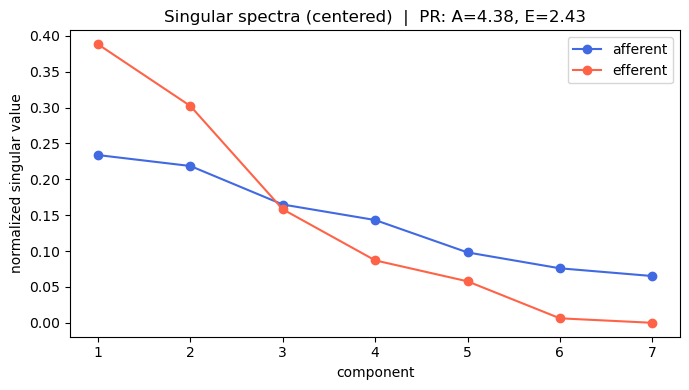

In [2]:
def participation_ratio(X):
    s2 = np.linalg.svd(X, compute_uv=False)**2
    return (s2.sum()**2) / (s2**2).sum()

PR = {'A_uncentered': participation_ratio(A),        'E_uncentered': participation_ratio(E),
      'A_centered':   participation_ratio(A-A.mean(0)),'E_centered':   participation_ratio(E-E.mean(0))}
print('Participation ratio (effective dimensionality, max = 7):')
for k, v in PR.items(): print(f'  {k:14s} {v:.3f}')
print(f"\n=> afferent cloud is higher-dimensional than efferent "
      f"({PR['A_centered']:.2f} vs {PR['E_centered']:.2f} centered): the gap the map must explain.")

# singular spectra of A and E
fig, ax = plt.subplots(figsize=(7, 4))
for X, name, c in [(A-A.mean(0), 'afferent', 'royalblue'), (E-E.mean(0), 'efferent', 'tomato')]:
    s = np.linalg.svd(X, compute_uv=False)
    ax.plot(np.arange(1, n_sub+1), s/ s.sum(), 'o-', color=c, label=name)
ax.set_xlabel('component'); ax.set_ylabel('normalized singular value')
ax.set_title(f'Singular spectra (centered)  |  PR: A={PR["A_centered"]:.2f}, E={PR["E_centered"]:.2f}')
ax.legend(); fig.tight_layout(); fig.savefig(OUTDIR/'m0_singular_spectra.png', dpi=120); plt.show()

### Module 0 explained — effective dimensionality

**Intuitively.** Each region is one point in a 7-dimensional space (its profile across the 7 HPC
subregions), so afferent and efferent are each a *cloud* of 72 points. "Effective dimensionality"
asks a simple question: **how many independent directions does the cloud actually fill?** If the
points nearly lie on a line, it's ~1-D; if they spread evenly in all 7 directions, it's ~7-D. It's
a soft, continuous count that down-weights directions with little spread.

**Mathematically.** Take the singular values $\sigma_1 \ge \dots \ge \sigma_7$ of the data matrix
(equivalently the eigenvalues $\lambda_i = \sigma_i^2$ of its covariance — the variance along each
principal axis). The **participation ratio** is
$$\mathrm{PR} = \frac{\left(\sum_i \sigma_i^2\right)^2}{\sum_i \sigma_i^4} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}.$$
If one direction dominates, $\mathrm{PR}\to 1$; if $k$ directions carry equal variance and the rest
none, $\mathrm{PR}=k$. It's the same "participation ratio / $n_2$" from `effective_dimensionality.ipynb`,
here bounded by 7. *Centered* subtracts the mean (spread about the centroid); *uncentered* keeps the
mean direction too.

**What we found.** The afferent cloud is clearly higher-dimensional than the efferent cloud:
$\mathrm{PR}_A = 4.39$ vs $\mathrm{PR}_E = 2.43$ (centered; $3.31$ vs $2.57$ uncentered). So HPC's
*inputs* spread across ~4–5 effective dimensions while its *outputs* occupy only ~2–3 — a gap of
roughly **two dimensions**. That gap is the single fact the rest of the notebook sets out to explain
as a compressive map. (Note the efferent DG column is all-zero — DG projects nowhere — so the
efferent cloud can use at most 6 dimensions to begin with.)

## Module 1 — Orthogonal Procrustes (diagnostic baseline, *not* the model)

Best rotation/reflection `R` (`RᵀR = I`) minimizing `‖E − A R‖_F`. Because profiles are on the
sphere, `A R` stays on `S⁶` — a clean rigid alignment. A rotation **cannot** reduce dimensionality,
so we *expect a structured, large residual*; that leftover is the compressive part the next module
captures. We report fit quality and the **residual's own singular spectrum**, and treat this as the
baseline the compressive model must beat.

In [3]:
R, _ = orthogonal_procrustes(A, E)                       # A R ~ E
resid_proc = E - A @ R
ss_res = (resid_proc**2).sum()
r2_uncentered = 1 - ss_res / (E**2).sum()                    # baseline = origin (sphere)
r2_centered   = 1 - ss_res / ((E - E.mean(0))**2).sum()      # baseline = mean efferent profile
resid_sv = np.linalg.svd(resid_proc, compute_uv=False)
print(f'Procrustes fit:  ||E - A R||_F^2 = {ss_res:.2f}')
print(f'  R^2 vs origin (uncentered) = {r2_uncentered:.3f}')
print(f'  R^2 vs mean   (centered)   = {r2_centered:.3f}')
print(f'  residual singular spectrum = {np.round(resid_sv, 3)}')
print('  -> a single rotation is a poor per-region model (as predicted): the residual is high-rank,')
print('     i.e. structure a rigid map leaves behind. The compressive model (Module 2) must beat this.')

Procrustes fit:  ||E - A R||_F^2 = 54.46
  R^2 vs origin (uncentered) = 0.244
  R^2 vs mean   (centered)   = -0.416
  residual singular spectrum = [4.719 3.339 3.271 2.055 1.807 1.263 1.118]
  -> a single rotation is a poor per-region model (as predicted): the residual is high-rank,
     i.e. structure a rigid map leaves behind. The compressive model (Module 2) must beat this.


### Module 1 explained — orthogonal Procrustes

**Intuitively.** Ask the simplest possible question first: *is the output just a rigidly rotated copy
of the input?* Picture both clouds as constellations on the sphere and find the single rotation (spin
+ optional flip) that best lays the afferent constellation on top of the efferent one, region by
region. A rotation can reorient but **cannot stretch, squash, or collapse** — it preserves every
distance and the cloud's dimensionality. So this is a deliberately rigid baseline: if a rotation
explained everything, input and output would be the same shape, merely reoriented.

**Mathematically.** Orthogonal Procrustes finds $R$ ($7\times 7$, $R^\top R = I$) minimizing
$\lVert E - A R\rVert_F$. Closed form: SVD $A^\top E = U\Sigma V^\top$, then $R = U V^\top$. Because
$R$ is orthogonal it preserves norms and maps the sphere to itself, so $AR$ stays on $S^6$ — a clean
rigid alignment. We score it with variance explained, and inspect the **residual's singular spectrum**
(a rotation cannot reduce rank, so leftover structure is expected).

**What we found.** The rotation fits **poorly**, exactly as the compression premise predicts:
$\lVert E - AR\rVert_F^2 = 54.5$, with $R^2 = -0.42$ against the mean (worse than just guessing the
average efferent profile) and $0.24$ against the origin. The residual's singular spectrum
$[4.7, 3.3, 3.3, 2.1, 1.8, 1.3, 1.1]$ is **high-rank and flat** — the leftover has structure in every
direction, not concentrated anywhere. So no rigid map can be the story (input is higher-dimensional
than output, and rotations preserve dimensionality); that large, high-rank residual *is* the
compression Module 2 models. Importantly, the later permutation test still shows this rotation beats
random region pairings ($p = 0.001$) — there **is** real input/output correspondence, just not a rigid one.

## Module 2 — Reduced-rank regression (the model + collapsed subspace)

"efferent dim < afferent dim" is a statement about the **rank of the map**. We model `e_i = M a_i`
(column-vector convention), i.e. `E ≈ A B` with `B = Mᵀ`. Fit OLS `B̂ = A⁺E`, then constrain to
rank `k` (classic RRR: truncate the fitted response `A B̂` to its top-`k` output directions). We
pick `k` by **leave-one-region-out CV**.

**Collapsed-subspace readout (key result):** the **right-singular vectors of `M` with near-zero
singular values** are the afferent directions (in HPC-subregion space) the map *throws away*.
Per region, its **loading onto that collapsed subspace** flags whose input-side distinctions are
not preserved on the output side.

LOO-CV reconstruction error by rank k: [0.5512 0.5526 0.5577 0.5605 0.5596 0.5596 0.5596]
  -> selected effective rank k* = 1  (CV curve is fairly flat: rank is weakly determined,
     but low rank is favored -> a strongly COMPRESSIVE map, consistent with the PR gap)
M singular spectrum: [1.086 0.757 0.536 0.415 0.168 0.006 0.   ]
collapsed input subspace dimension = 6
regions loading most on the collapsed (thrown-away) input subspace:
  AMd (0.99), LSc.v (0.99), SF (0.99), LSc.d (0.99), PERI (0.97), RSPv.b/c (0.97), IAM (0.95), NDB (0.95)


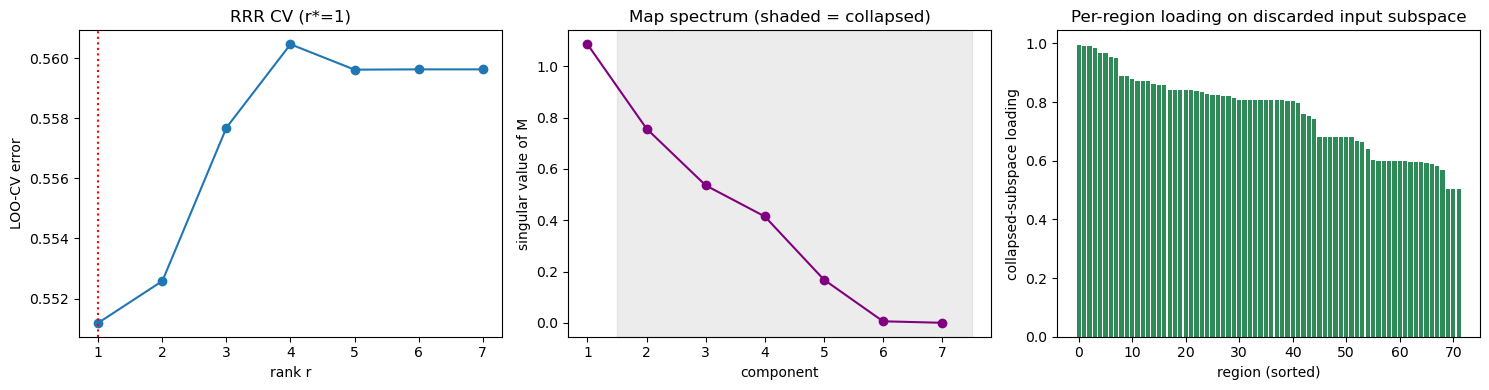


CONCRETE READOUT: the afferent-efferent dimensionality gap is carried by a 6-D input subspace loaded most by {AMd, LSc.v, SF, LSc.d, PERI, ...}, which HPC output does not distinguish.


In [4]:
def ols_B(Ain, Ein):            # E ~ A B ; B is n_sub x n_sub
    return np.linalg.pinv(Ain) @ Ein

def rrr_B(Ain, Ein, k):         # rank-k reduced-rank regression coefficient (Frobenius error metric)
    B = ols_B(Ain, Ein)
    Vt = np.linalg.svd(Ain @ B, full_matrices=False)[2]     # top output directions of fitted response
    Qk = Vt[:k].T
    return B @ Qk @ Qk.T

def loo_cv_error(Ain, Ein, k):  # leave-one-region-out reconstruction error of E from A at rank k
    n = len(Ain); err = 0.0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        err += np.sum((Ein[i] - Ain[i] @ rrr_B(Ain[m], Ein[m], k))**2)
    return err / n

cv = np.array([loo_cv_error(A, E, k) for k in range(1, n_sub+1)])
k_star = int(np.argmin(cv) + 1)
B_ols = ols_B(A, E); M = B_ols.T                            # geometric map e = M a
sv_M = np.linalg.svd(M, compute_uv=False)
Um, Sm, VmT = np.linalg.svd(M); Vm = VmT.T                  # right singular vectors of M (input space)
collapsed = Vm[:, k_star:]                                  # input directions the rank-k map discards
load = np.linalg.norm(A @ collapsed, axis=1)                # per-region loading on collapsed subspace

print(f'LOO-CV reconstruction error by rank k: {np.round(cv, 4)}')
print(f'  -> selected effective rank k* = {k_star}  (CV curve is fairly flat: rank is weakly determined,')
print(f'     but low rank is favored -> a strongly COMPRESSIVE map, consistent with the PR gap)')
print(f'M singular spectrum: {np.round(sv_M, 3)}')
print(f'collapsed input subspace dimension = {collapsed.shape[1]}')
top_load = np.argsort(load)[::-1][:8]
print('regions loading most on the collapsed (thrown-away) input subspace:')
print('  ' + ', '.join(f'{regions[i]} ({load[i]:.2f})' for i in top_load))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(range(1, n_sub+1), cv, 'o-'); ax[0].axvline(k_star, color='red', ls=':')
ax[0].set_xlabel('rank r'); ax[0].set_ylabel('LOO-CV error'); ax[0].set_title(f'RRR CV (r*={k_star})')
ax[1].plot(range(1, n_sub+1), sv_M, 'o-', color='purple')
ax[1].axvspan(k_star+0.5, n_sub+0.5, color='gray', alpha=0.15)
ax[1].set_xlabel('component'); ax[1].set_ylabel('singular value of M'); ax[1].set_title('Map spectrum (shaded = collapsed)')
order = np.argsort(load)[::-1]
ax[2].bar(range(n_regions), load[order], color='seagreen')
ax[2].set_xlabel('region (sorted)'); ax[2].set_ylabel('collapsed-subspace loading')
ax[2].set_title('Per-region loading on discarded input subspace')
fig.tight_layout(); fig.savefig(OUTDIR/'m2_rrr.png', dpi=120); plt.show()

print(f'\nCONCRETE READOUT: the afferent-efferent dimensionality gap is carried by a '
      f'{collapsed.shape[1]}-D input subspace loaded most by {{'
      + ', '.join(regions[i] for i in top_load[:5]) + ', ...}, which HPC output does not distinguish.')

> **Caveat — the map is low-rank *and* weak.** "Rank-1 is selected" describes the *structure* of the
> fit, not a validated predictive law. The afferent→efferent map explains very little efferent variance:
> **in-sample $R^2 \approx 0.03$ at rank 1** (rising only to ~0.18 at full rank), and the **leave-one-out
> held-out $R^2$ is $\approx 0$ — in fact slightly *negative* at every rank** (it does not beat predicting
> the mean efferent profile). So a region's afferent profile does **not** meaningfully predict its
> efferent profile out-of-sample.
>
> Read the RRR outputs accordingly:
> - The **rank selection** is really "no rank generalizes; rank 1 is the *least-overfit*," not "a
>   validated rank-1 transformation."
> - The **collapsed subspace** and the **ventral kept-axis** describe the geometry of the *in-sample*
>   least-squares fit — useful as description, but not a strong mechanism, since the fit itself is faint.
> - This is consistent with Module 4: CCA finds moderate canonical *correlations* (~0.75) because those
>   live in **low-variance** directions that carry little of the total variance — correlation without
>   much variance-explained. It is also why Module 2 (predictive) and Module 3 (variance) diverge.
>
> Bottom line: the "compression" is real as a statement about the **rank** of the best-fit map, but the
> map is a weak predictor, so the input→output relationship should be described cautiously rather than as
> a strong geometric law.

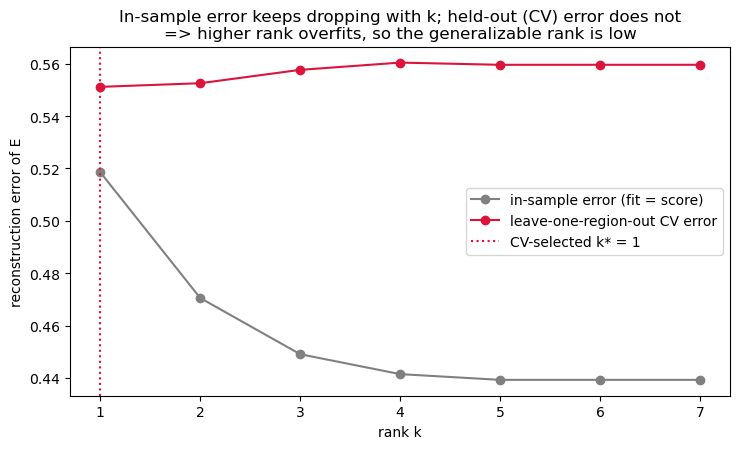

In [5]:
# --- Why the CV minimum can sit at LOW rank: in-sample vs held-out error ---
# In-sample error (fit AND score on all 72 regions) can only improve as rank grows -- more
# freedom always fits the data you already have. That is your intuition, and it's correct...
# ...but it is the wrong yardstick. LOO-CV error (predict a region held OUT) is what we select
# on; extra ranks fit region-specific NOISE that does not transfer, so held-out error stops
# improving (here it slightly worsens). The honest rank is where CV -- not in-sample -- bottoms out.
insample = np.array([np.sum((E - A @ rrr_B(A, E, k))**2) / n_regions for k in range(1, n_sub + 1)])

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(range(1, n_sub + 1), insample, 'o-', color='gray',   label='in-sample error (fit = score)')
ax.plot(range(1, n_sub + 1), cv,       'o-', color='crimson', label='leave-one-region-out CV error')
ax.axvline(k_star, color='crimson', ls=':', label=f'CV-selected k* = {k_star}')
ax.set_xlabel('rank k'); ax.set_ylabel('reconstruction error of E')
ax.set_title('In-sample error keeps dropping with k; held-out (CV) error does not\n'
             '=> higher rank overfits, so the generalizable rank is low')
ax.legend(); fig.tight_layout(); fig.savefig(OUTDIR / 'm2b_insample_vs_cv.png', dpi=120); plt.show()

### Which subfields does the low-rank map keep?

Not a single one. A rank-1 map keeps **one direction** in subfield space, which is a weighted
*combination* of the 7 subfields — a separate combination on the input and output sides. The
prediction is `Ê = (A w) · Q₁ᵀ`: a single **input combination** `w` (afferent-subfield weights)
drives a single **output combination** `Q₁` (efferent-subfield weights). Reading off the weights
below shows which subfields dominate each side. (A univariate check confirms *no single subfield*
predicts well on its own — the signal is genuinely multivariate.)

In [ ]:
np.round(Q, 2)

In [ ]:
Q[:2]

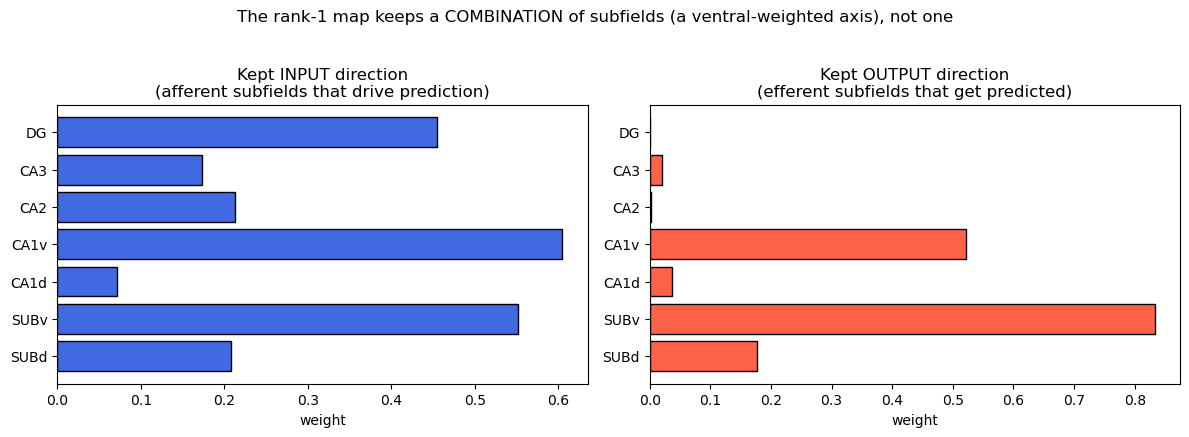

Kept INPUT (afferent) subfield weights [top component]:
   CA1v  +0.605
   SUBv  +0.551
   DG    +0.455
   CA2   +0.213
   SUBd  +0.208
   CA3   +0.174
   CA1d  +0.071
Kept OUTPUT (efferent) subfield weights [top component]:
   SUBv  +0.833
   CA1v  +0.522
   SUBd  +0.177
   CA1d  +0.038
   CA3   +0.021
   CA2   +0.002
   DG    +0.000

Univariate LOO-CV R^2 (one afferent subfield alone predicting E):
   DG    R^2 = -0.756
   CA3   R^2 = -0.673
   CA2   R^2 = -0.836
   CA1v  R^2 = -0.280
   CA1d  R^2 = -0.816
   SUBv  R^2 = -0.327
   SUBd  R^2 = -0.785
=> every single subfield alone is worse than predicting the mean; prediction needs the combination.


In [8]:
# The rank-k map's kept INPUT and OUTPUT directions, as weights over the 7 subfields.
Bfit = ols_B(A, E)
Q = np.linalg.svd(A @ Bfit, full_matrices=False)[2]          # output-space singular directions
in_dir  = Bfit @ Q[:k_star].T                                # afferent (input) weights per kept comp
in_dir /= np.linalg.norm(in_dir, axis=0, keepdims=True)
out_dir = Q[:k_star].T                                       # efferent (output) weights per kept comp
for c in range(k_star):                                      # sign: largest-|input| entry positive
    if in_dir[np.argmax(np.abs(in_dir[:, c])), c] < 0:
        in_dir[:, c] *= -1; out_dir[:, c] *= -1

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2)); y = np.arange(n_sub)
ax[0].barh(y, in_dir[:, 0], color='royalblue', edgecolor='k'); ax[0].axvline(0, color='k', lw=0.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(subs); ax[0].invert_yaxis()
ax[0].set_xlabel('weight'); ax[0].set_title('Kept INPUT direction\n(afferent subfields that drive prediction)')
ax[1].barh(y, out_dir[:, 0], color='tomato', edgecolor='k'); ax[1].axvline(0, color='k', lw=0.5)
ax[1].set_yticks(y); ax[1].set_yticklabels(subs); ax[1].invert_yaxis()
ax[1].set_xlabel('weight'); ax[1].set_title('Kept OUTPUT direction\n(efferent subfields that get predicted)')
fig.suptitle(f'The rank-{k_star} map keeps a COMBINATION of subfields (a ventral-weighted axis), not one',
             y=1.03)
fig.tight_layout(); fig.savefig(OUTDIR / 'm2c_kept_directions.png', dpi=120); plt.show()

print('Kept INPUT (afferent) subfield weights [top component]:')
for s, v in sorted(zip(subs, in_dir[:, 0]), key=lambda t: -abs(t[1])): print(f'   {s:5s} {v:+.3f}')
print('Kept OUTPUT (efferent) subfield weights [top component]:')
for s, v in sorted(zip(subs, out_dir[:, 0]), key=lambda t: -abs(t[1])): print(f'   {s:5s} {v:+.3f}')

# Univariate cross-check: LOO-CV variance-explained using ONE afferent subfield at a time.
tot = np.sum((E - E.mean(0))**2)
print('\nUnivariate LOO-CV R^2 (one afferent subfield alone predicting E):')
for j, s in enumerate(subs):
    aj = A[:, [j]]; err = 0.0
    for i in range(n_regions):
        m = np.ones(n_regions, bool); m[i] = False
        err += np.sum((E[i] - aj[i] @ (np.linalg.pinv(aj[m]) @ E[m]))**2)
    print(f'   {s:5s} R^2 = {1 - err/tot:+.3f}')
print('=> every single subfield alone is worse than predicting the mean; prediction needs the combination.')

### Seeing the rank-1 bottleneck: predicted vs true profiles

The rank-1 map can only emit **scaled copies of a single shape** `Q₁` (the ventral output direction).
Below, the *true* efferent profiles of a few example regions (chosen to span the score range) each
have a **different shape**, while their *rank-1 predictions* are all the **same ventral shape**,
differing only in height (= the region's score). That inability to vary the output shape is the
compression, made visible.

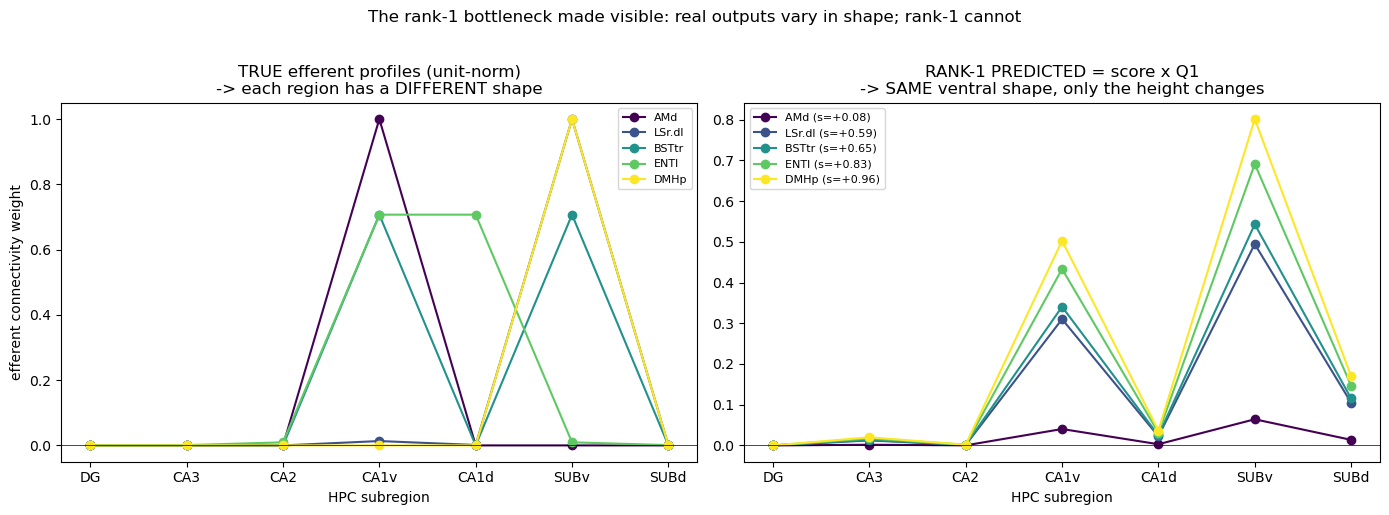

Every rank-1 predicted profile is a scalar multiple of Q1 (same shape); the score sets the height.
Example scores: {'AMd': 0.08, 'LSr.dl': 0.59, 'BSTtr': 0.65, 'ENTl': 0.83, 'DMHp': 0.96}


In [9]:
# Rank-1 predictions all share ONE shape (Q1), scaled per region by its score s_i.
B1 = rrr_B(A, E, 1)                                  # rank-1 coefficient (equals k*=1 here)
Ehat1 = A @ B1                                       # rank-1 predicted efferent profiles (not unit-norm)
Bfit = ols_B(A, E)
Q1 = np.linalg.svd(A @ Bfit, full_matrices=False)[2][0]
wprime = Bfit @ Q1
scores = A @ wprime                                  # per-region score s_i  (e_hat_i = s_i * Q1)
if wprime[np.argmax(np.abs(wprime))] < 0:            # sign convention (largest input weight positive)
    Q1, scores = -Q1, -scores

order = np.argsort(scores)
picks = order[np.linspace(0, len(order) - 1, 5).round().astype(int)]   # regions spanning the score range
x = np.arange(n_sub); colors = plt.cm.viridis(np.linspace(0, 1, len(picks)))

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for c, i in zip(colors, picks):
    ax[0].plot(x, E[i],     'o-', color=c, label=regions[i])
    ax[1].plot(x, Ehat1[i], 'o-', color=c, label=f'{regions[i]} (s={scores[i]:+.2f})')
ax[0].set_title('TRUE efferent profiles (unit-norm)\n-> each region has a DIFFERENT shape')
ax[1].set_title('RANK-1 PREDICTED = score x Q1\n-> SAME ventral shape, only the height changes')
for a_ in ax:
    a_.set_xticks(x); a_.set_xticklabels(subs); a_.set_xlabel('HPC subregion')
    a_.axhline(0, color='k', lw=0.5); a_.legend(fontsize=8)
ax[0].set_ylabel('efferent connectivity weight')
fig.suptitle('The rank-1 bottleneck made visible: real outputs vary in shape; rank-1 cannot', y=1.02)
fig.tight_layout(); fig.savefig(OUTDIR / 'm2d_rank1_profiles.png', dpi=120); plt.show()

print('Every rank-1 predicted profile is a scalar multiple of Q1 (same shape); the score sets the height.')
print('Example scores:', {regions[i]: round(float(scores[i]), 2) for i in picks})

### Module 2 explained — reduced-rank regression (the model)

**Intuitively.** Now we look for the rule HPC uses to turn input into output, but we force it through
a **bottleneck**: squeeze the 7-D input down to a few summary numbers, then expand back to a 7-D
output. "Rank" is the width of that bottleneck. Because the output cloud is lower-dimensional, a narrow
bottleneck should be enough — and *how narrow* tells us how much input information is thrown away.
**Cross-validation** (hide one region, predict it from the rest) picks the honest width: a wider
bottleneck always fits the data you already have, but past a point it just memorizes noise and predicts
new regions *worse*. The input directions the bottleneck discards — the **collapsed subspace** — are
the input distinctions that never reach the output.

**Mathematically.** Model $E \approx A B$; ordinary least squares gives $\hat B = A^{+}E$. Rank-$k$
RRR minimizes $\lVert E - AB\rVert_F$ subject to $\mathrm{rank}(B)\le k$, solved by projecting the
fitted response onto its top-$k$ output directions: $\hat Y = A\hat B = U\Sigma V^\top$,
$B_k = \hat B\,V_k V_k^\top$. Reading the map on vectors, $e \approx M a$ with $M = B^\top$; its SVD
$M = U\Sigma V^\top$ makes the prediction an **encode→decode**: $\hat e = \sum_{j\le k}(a\cdot w_j)\,Q_j$
(project onto input directions $w_j$, rebuild from output directions $Q_j$). The **collapsed subspace**
is the right-singular vectors of $M$ with $\sigma\approx 0$. The key identity: if $\mathrm{rank}(B)=k$
then $\mathrm{rank}(E)\le\min(\mathrm{rank}\,A,\,k)$ — a low-rank map *forces* a low-D output, which is
the mechanism behind the Module 0 gap. Rank is chosen by leave-one-region-out CV.

**What we found.** The map is **strongly compressive**: LOO-CV error
$[0.551, 0.553, 0.558, 0.560, \dots]$ is lowest at $k^* = 1$ (and *rises* with rank — the overfitting
the in-sample-vs-CV plot makes explicit). The curve is nearly flat, so the *exact* rank is weakly
pinned down, but low rank is clearly favored. The map's singular spectrum
$[1.09, 0.76, 0.54, 0.42, 0.17, 0.006, 0]$ leaves a **6-D collapsed input subspace**, loaded most by
**AMd, LSc.v, SF, LSc.d, PERI** — regions whose afferent distinctions HPC output does not preserve.
The one retained axis is **ventral**: it reads a ventral-weighted afferent score (CA1v +0.61, SUBv
+0.55, DG +0.46) and writes it almost entirely onto ventral efferent subfields (SUBv +0.83, CA1v +0.52).
No single subfield predicts on its own (every univariate LOO-CV $R^2<0$; CA1v least-bad at $-0.28$) —
the signal is genuinely a *combination*. The final panel shows the consequence: every rank-1 predicted
profile is the **same ventral shape**, scaled per region by its score.

### Is the poor fit driven by a few outlier regions?

The held-out $R^2 \approx 0$ (slightly negative) admits an interesting interpretation: maybe there
is **no single global rule** mapping afferent → efferent, and the input→output relationship is
region-idiosyncratic. But a competing, more mundane possibility is that a **handful of outlier
regions** wreck an otherwise-decent global fit. This cell tests that directly.

We rank regions two ways and remove the top offenders, refitting on the remainder:

1. **collapsed-subspace loading** (the requested test) — regions whose afferent profile lies most in
   the directions the map discards;
2. **rank-1 residual magnitude** — the more direct "outlier" criterion: the regions the fit predicts
   worst.

If a few outliers were the problem, removing them should push $R^2$ **up**. We report both in-sample
and leave-one-out $R^2$ (vs the mean-profile baseline) as regions are dropped.

corr(collapsed-loading, residual) = 0.49; top-10 sets overlap = 5/10

remove top regions by collapsed-loading:
   drop  0 (n=72): in-sample R2=+0.029   LOO R2=-0.003
   drop  5 (n=67): in-sample R2=+0.007   LOO R2=-0.030
   drop 10 (n=62): in-sample R2=+0.006   LOO R2=-0.035
   drop 15 (n=57): in-sample R2=+0.011   LOO R2=-0.023
   drop 20 (n=52): in-sample R2=+0.015   LOO R2=-0.030

remove top regions by residual:
   drop  0 (n=72): in-sample R2=+0.029   LOO R2=-0.003
   drop  5 (n=67): in-sample R2=+0.029   LOO R2=-0.011
   drop 10 (n=62): in-sample R2=-0.008   LOO R2=-0.060
   drop 15 (n=57): in-sample R2=-0.026   LOO R2=-0.069
   drop 20 (n=52): in-sample R2=-0.014   LOO R2=-0.055



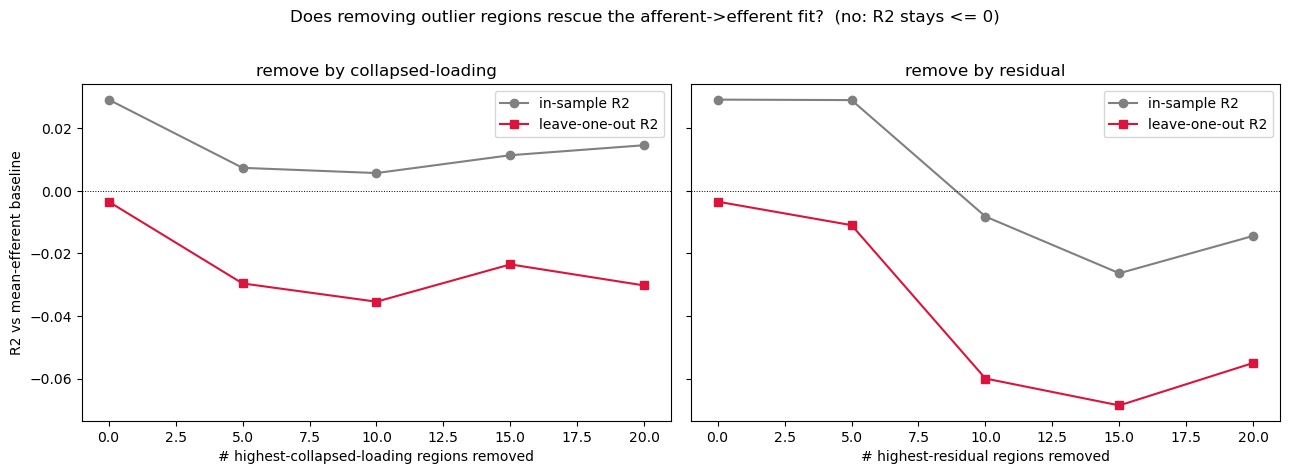

VERDICT: removing outliers does NOT lift held-out R2 above ~0 -> the poor fit is PERVASIVE, not caused by a few regions.


In [10]:
# Rank regions by two outlier criteria (both from the full-data rank-k* fit), then remove the top
# offenders and refit on the remainder. Reuses ols_B / rrr_B / k_star / collapsed / load from above.
resid_full = np.linalg.norm(E - A @ rrr_B(A, E, k_star), axis=1)   # per-region rank-1 residual
loading_full = load                                                # collapsed-subspace loading (from Module 2)

print(f'corr(collapsed-loading, residual) = {spearmanr(loading_full, resid_full).correlation:.2f}; '
      f'top-10 sets overlap = '
      f'{len(set(np.argsort(loading_full)[::-1][:10]) & set(np.argsort(resid_full)[::-1][:10]))}/10\n')

def r2_vs_mean(Ai, Ei, k, loo=False):
    # R^2 against the mean-efferent baseline; loo=True -> leave-one-region-out (honest), else in-sample.
    if not loo:
        return 1 - ((Ei - Ai @ rrr_B(Ai, Ei, k))**2).sum() / ((Ei - Ei.mean(0))**2).sum()
    n = len(Ai); err = errm = 0.0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        err  += np.sum((Ei[i] - Ai[i] @ rrr_B(Ai[m], Ei[m], k))**2)
        errm += np.sum((Ei[i] - Ei[m].mean(0))**2)
    return 1 - err / errm

drops = [0, 5, 10, 15, 20]
results = {}
for crit_name, crit in [('collapsed-loading', loading_full), ('residual', resid_full)]:
    order = np.argsort(crit)                        # ascending: keep the low-criterion regions
    ins, loo = [], []
    for d in drops:
        keep = order[:len(A) - d]                   # drop the top-d offenders
        ins.append(r2_vs_mean(A[keep], E[keep], k_star, loo=False))
        loo.append(r2_vs_mean(A[keep], E[keep], k_star, loo=True))
    results[crit_name] = (ins, loo)
    print(f'remove top regions by {crit_name}:')
    for d, a, b in zip(drops, ins, loo):
        print(f'   drop {d:2d} (n={len(A)-d}): in-sample R2={a:+.3f}   LOO R2={b:+.3f}')
    print()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for a_, (crit_name, (ins, loo)) in zip(ax, results.items()):
    a_.plot(drops, ins, 'o-', label='in-sample R2', color='gray')
    a_.plot(drops, loo, 's-', label='leave-one-out R2', color='crimson')
    a_.axhline(0, color='k', lw=0.7, ls=':')
    a_.set_xlabel('# highest-%s regions removed' % crit_name); a_.set_title('remove by %s' % crit_name)
    a_.legend()
ax[0].set_ylabel('R2 vs mean-efferent baseline')
fig.suptitle('Does removing outlier regions rescue the afferent->efferent fit?  (no: R2 stays <= 0)', y=1.02)
fig.tight_layout(); fig.savefig(OUTDIR / 'm2_outlier_test.png', dpi=120); plt.show()

improved = max(results['collapsed-loading'][1][1:] + results['residual'][1][1:]) > results['collapsed-loading'][1][0] + 0.05
print('VERDICT: removing outliers does NOT lift held-out R2 above ~0 '
      f'-> the poor fit is PERVASIVE, not caused by a few regions.'
      if not improved else 'VERDICT: some outliers were degrading the fit (R2 improved on removal).')

**What this shows.** Removing the top offenders — by either criterion — does **not** lift held-out
$R^2$ above ~0; it stays flat or drifts slightly *negative*. So the weak fit is **pervasive**, not the
work of a few outlier regions. No well-behaved core with a clean global rule is hiding underneath.
(The slight worsening is partly a sample-size effect — dropping regions shrinks the training set — so
the honest reading is "**no improvement**," not "outliers were helping.")

**How this bears on your interpretation.**

- ✅ **Supported: there is no global *linear* rule** mapping afferent → efferent profiles across
  regions. Knowing a region's input profile does not predict its output profile better than the
  population-average output — and that holds region-wide, not just for outliers.
- ⚠️ **"Idiosyncratic compression" — needs care.** A single global regression **cannot distinguish**
  "no afferent→efferent relationship" from "each region has its own private transformation": both
  produce $R^2 \approx 0$. And a per-region map is **not estimable** here — each region is a single
  input→output pair, so there is no within-region transformation to fit. What we *can* say precisely:
  the efferent cloud's lower dimensionality (Module 0/3) is **not produced by a systematic transform of
  the afferent profiles** — input and output are largely **decoupled at the region level**. The
  "compression" is a property of the *output distribution*, not of an input→output mapping.
- **Caveats.** RRR is linear, so this rules out a *linear* global rule, not a nonlinear one; and at
  $n = 72$ the test is underpowered, so a weak real signal could sit below detection.

So your instinct is right in its strong form — **the shared global transformation the pipeline set out
to find is essentially absent** — but the positive claim should be "input and output are decoupled at
the region level," rather than "each region compresses idiosyncratically," which this data cannot
establish.

### Could we use *all* partner regions, not just the 72 bidirectional ones?

Only **72** regions have *both* an afferent and an efferent profile. But **96** regions project to HPC
(afferent) and **165** receive from it (efferent). Natural question: train the map on the larger sets —
"predict the 165 outputs using all 96 inputs."

**Short answer: not as a single reduced-rank regression.** RRR is a *paired* model — it learns a
mapping from each region's input vector to that *same region's* output vector, so a training example
needs **both** halves. That restricts training/testing to the **72 shared** regions:

- the **93** efferent-only regions (receive but don't project) have **no afferent input**, so the model
  has nothing to predict *from* — they are unreachable;
- the **24** afferent-only regions (project but don't receive) have an input but **no efferent target**,
  so they can't be used to *fit* the map, and any prediction for them can't be *validated*.

What the extra regions *can* legitimately do: (a) let us **impute** efferent profiles for the 24
afferent-only regions (prediction without ground truth), and (b) re-estimate each side's **marginal
dimensionality** on the larger samples — a real robustness check on the afferent > efferent asymmetry.
(Using unpaired data to actually *learn* the map would require a different, latent-variable model — and
given the paired signal is already ≈ 0, that isn't worth it here.)

In [11]:
# Build afferent (project->HPC) and efferent (HPC->receive) profiles for the FULL partner sets.
df_conn = pd.read_csv('../data/average_connectome_data.csv', header=0, index_col=0).fillna(0.0)
non_hpc = [r for r in df_conn.index if r not in subs]        # subs = 7 HPC subregions
aff_sources = [r for r in non_hpc if (df_conn.loc[r, subs].values > 0).any()]   # region -> HPC
eff_targets = [r for r in non_hpc if (df_conn.loc[subs, r].values > 0).any()]   # HPC -> region
shared72 = sorted(set(aff_sources) & set(eff_targets))
aff_only = sorted(set(aff_sources) - set(eff_targets))       # project, don't receive
eff_only = sorted(set(eff_targets) - set(aff_sources))       # receive, don't project
print(f'afferent sources={len(aff_sources)}  efferent targets={len(eff_targets)}  shared={len(shared72)}'
      f'  |  afferent-only={len(aff_only)}  efferent-only={len(eff_only)}  union={len(set(aff_sources)|set(eff_targets))}')

def build_profiles(region_list, incoming):
    # incoming=True -> afferent (region->HPC, df[r,s]); False -> efferent (HPC->region, df[s,r]).
    raw = np.array([[df_conn.loc[r, s] if incoming else df_conn.loc[s, r] for s in subs]
                    for r in region_list], float)
    X = log_weight_transform(raw)
    nrm = np.linalg.norm(X, axis=1, keepdims=True); nrm[nrm == 0] = 1.0
    return X / nrm

# (a) Impute efferent for the 24 afferent-only regions, using the map trained on the 72 shared.
W72 = rrr_B(A, E, k_star)                                    # A, E are the shared-72 profiles from Module 2
A_only = build_profiles(aff_only, incoming=True)
E_imputed = A_only @ W72
E_imputed /= np.linalg.norm(E_imputed, axis=1, keepdims=True)
# How discriminative are the imputations? Compare their spread to the real efferent spread.
E_mean_dir = E.mean(0) / np.linalg.norm(E.mean(0))
cos_to_mean = E_imputed @ E_mean_dir
print(f'\nImputed efferent for {len(aff_only)} afferent-only regions (UNVALIDATED -- no ground truth).')
print(f'  their cosine-to-mean-efferent: mean={cos_to_mean.mean():.2f}, sd={cos_to_mean.std():.2f} '
      f'-> they collapse toward the mean output (expected: the map is a weak predictor, so imputations')
print(f'     carry little region-specific information). The {len(eff_only)} efferent-only regions cannot '
      f'be predicted at all (no input).')

# (b) Robustness of the dimensionality asymmetry on the FULL sets (this genuinely uses all regions).
def pr(X):
    l = np.linalg.svd(X - X.mean(0), compute_uv=False)**2; return (l.sum()**2) / (l**2).sum()
A_full, E_full = build_profiles(aff_sources, True), build_profiles(eff_targets, False)
print(f'\nParticipation ratio (effective dimensionality):')
print(f'  afferent: n=72 -> {pr(A):.2f}   |   n={len(aff_sources)} (all sources)  -> {pr(A_full):.2f}')
print(f'  efferent: n=72 -> {pr(E):.2f}   |   n={len(eff_targets)} (all targets) -> {pr(E_full):.2f}')
print('  -> the afferent > efferent spread asymmetry HOLDS (and strengthens) on the larger samples,')
print('     so it is not an artifact of restricting to the 72 bidirectional regions.')

afferent sources=96  efferent targets=165  shared=72  |  afferent-only=24  efferent-only=93  union=189


Imputed efferent for 24 afferent-only regions (UNVALIDATED -- no ground truth).
  their cosine-to-mean-efferent: mean=1.00, sd=0.00 -> they collapse toward the mean output (expected: the map is a weak predictor, so imputations
     carry little region-specific information). The 93 efferent-only regions cannot be predicted at all (no input).

Participation ratio (effective dimensionality):
  afferent: n=72 -> 4.38   |   n=96 (all sources)  -> 4.62
  efferent: n=72 -> 2.43   |   n=165 (all targets) -> 2.15
  -> the afferent > efferent spread asymmetry HOLDS (and strengthens) on the larger samples,
     so it is not an artifact of restricting to the 72 bidirectional regions.


**Takeaway.** The paired RRR can only be trained/tested on the 72 bidirectional regions — "use 96
inputs to predict 165 outputs" isn't a single regression, because 93 outputs have no input and 24
inputs have no output to learn from. We *can* impute efferent profiles for the 24 afferent-only regions,
but (i) there's no ground truth to check them and (ii) given the map's ≈ 0 predictive power they collapse
toward the mean output — so they carry little region-specific signal. The genuinely useful thing the
extra regions buy us is **confirmation that the dimensionality asymmetry is not an artifact of the
72-region restriction**: afferent PR stays ~4.4–4.6 and efferent ~2.2–2.4 on the full samples.

## Module 3 — Principal angles between subspaces (direct dimensionality story)

Compare the top-`k` PC subspaces of the (centered) afferent and efferent clouds. Directions with
**principal angle ≈ 90°** are afferent structure with *no* near-parallel efferent partner — the
geometry HPC output collapses. We cross-check that these agree with the collapsed subspace from
Module 2.

### Choosing the subspace dimension: permutation parallel analysis

Principal angles need an **integer** `k` (the dimension of each cloud's PC subspace). The
participation ratio from Module 0 is the wrong tool for that cut: it is a *soft* effective count
that down-weights small components rather than excluding them, so rounding it (e.g. 4.4 → 4) is a
decision the statistic never made.

Instead we set `k` by **permutation parallel analysis** (Horn 1965, permutation form):

- **Center** each subregion column (so the test is about covariance structure, matching the
  centered PCA the principal-angle cell uses — not the mean direction).
- **Shuffle the entries within each column independently.** This destroys cross-region structure
  (a region's value on one subregion is decoupled from its values on the others) while exactly
  preserving each subregion's marginal distribution.
- Recompute the singular values; repeat a few hundred times to build a **null envelope**.
- **Keep components whose observed singular value exceeds the null envelope** (here the 95th
  percentile of the null's `j`-th singular value). Each component is tested at the 5% level, so a
  spurious component slips through ~5% of the time — an error rate we can state. This is run
  **separately for `A` and `E`, so each adapts to its own noise level.**

**Two honest caveats surfaced by the run** (both reported below):

1. The subregion columns have very unequal variances (CA1v large, CA2 tiny). Column-permutation
   preserves those, so the covariance null's first singular value is inflated by the single
   dominant column, which can make component 1 look borderline. The **correlation** variant
   (standardize columns first) removes that and isolates cross-region structure — we report both.
2. A flat spectrum gives a *high* participation ratio yet *few* components above the noise floor:
   PR and parallel analysis answer different questions, and here they diverge for the afferent
   cloud. That divergence is the point — it is why rounding PR would have been misleading.

PERMUTATION PARALLEL ANALYSIS  (1000 perms, 95% envelope -> ~5% per-component false-positive)

COVARIANCE (centered; matches principal-angle cell)
  afferent: significant=[0 1 0 0 0 0 0]  k(contiguous)=0  k(count)=1
          p-values per component = [0.06  0.001 0.121 0.595 1.    1.    0.995]
  efferent: significant=[1 0 0 0 0 0 0]  k(contiguous)=1  k(count)=1
          p-values per component = [0.001 0.256 1.    1.    0.999 0.866 1.   ]

CORRELATION (standardized cols; isolates cross-region structure)
  afferent: significant=[1 1 1 0 0 0 0]  k(contiguous)=3  k(count)=3
          p-values per component = [0.009 0.001 0.012 0.875 0.974 0.996 1.   ]
  efferent: significant=[1 1 1 0 0 0 0]  k(contiguous)=3  k(count)=3
          p-values per component = [0.04  0.003 0.01  0.485 0.943 1.    1.   ]

-> using PA_SCALE='correlation': k_A=3, k_E=3  (dimensionality gap = 0)
   [other scale: covariance k_A=1, k_E=1 ; correlation k_A=3, k_E=3]


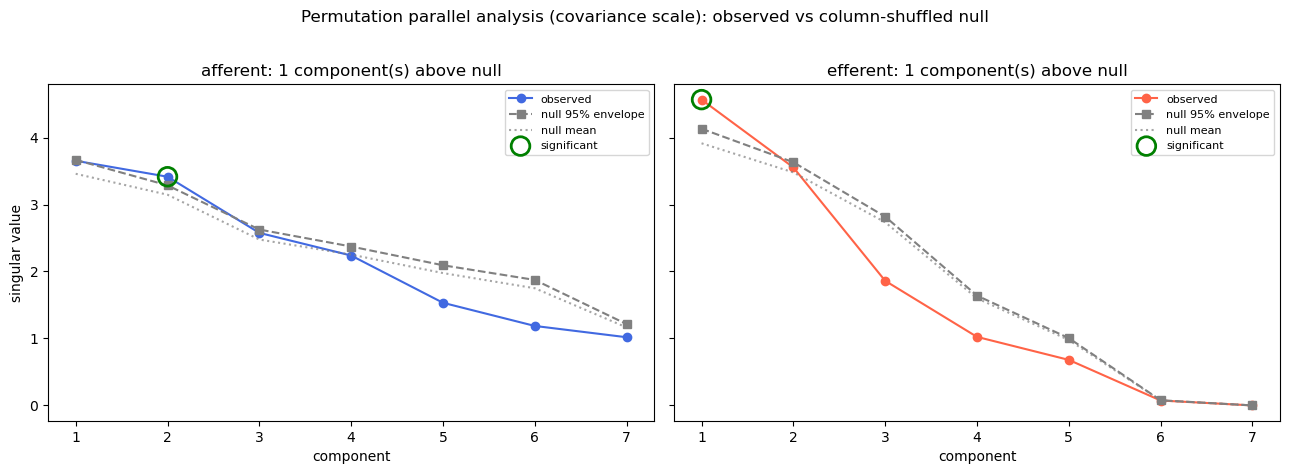

In [12]:
def parallel_analysis(X, standardize=False, n_perm=1000, pct=95, seed=SEED):
    # Permutation parallel analysis for the number of significant PCA components.
    #   standardize=False -> covariance scale (centered), consistent with the principal-angle cell.
    #   standardize=True  -> correlation scale (unit-variance columns): isolates cross-region
    #                        structure, immune to unequal column variances.
    rng = np.random.default_rng(seed)
    Xc = X - X.mean(0)                                     # center columns
    if standardize:
        sd = Xc.std(0, ddof=1); sd[sd < 1e-12] = 1.0; Xc = Xc / sd
    obs = np.linalg.svd(Xc, compute_uv=False)             # observed singular-value spectrum
    p = Xc.shape[1]
    null = np.empty((n_perm, p))
    for b in range(n_perm):
        Xp = np.column_stack([rng.permutation(Xc[:, j]) for j in range(p)])  # shuffle each col
        null[b] = np.linalg.svd(Xp, compute_uv=False)
    thr = np.percentile(null, pct, axis=0)                # null envelope (per component)
    pvals = (np.sum(null >= obs, axis=0) + 1) / (n_perm + 1)
    sig = obs > thr
    k_contig = p if sig.all() else int(np.argmax(~sig))   # stop at first non-significant component
    return dict(obs=obs, thr=thr, null_mean=null.mean(0), sig=sig, pvals=pvals,
                k_contig=k_contig, k_count=int(sig.sum()))

pa_cov = {name: parallel_analysis(X, standardize=False)
          for name, X in [('afferent', A), ('efferent', E)]}
pa_cor = {name: parallel_analysis(X, standardize=True)
          for name, X in [('afferent', A), ('efferent', E)]}

print('PERMUTATION PARALLEL ANALYSIS  (1000 perms, 95% envelope -> ~5% per-component false-positive)\n')
for scale, res in [('COVARIANCE (centered; matches principal-angle cell)', pa_cov),
                   ('CORRELATION (standardized cols; isolates cross-region structure)', pa_cor)]:
    print(scale)
    for name in ('afferent', 'efferent'):
        r = res[name]
        print(f'  {name}: significant={r["sig"].astype(int)}  '
              f'k(contiguous)={r["k_contig"]}  k(count)={r["k_count"]}')
        print(f'          p-values per component = {np.round(r["pvals"], 3)}')
    print()

# Integer dimensionality to use downstream. PA_SCALE selects which null the count comes from:
#   'correlation' -> standardized columns (immune to the CA1v>>CA2 variance imbalance); k_A=k_E=3 here.
#   'covariance'  -> centered only (matches the raw-metric PCA), but comp-1 is inflated by the
#                    dominant column, so it reads k_A=k_E=1. One-line switch.
PA_SCALE = 'correlation'
_pa = pa_cor if PA_SCALE == 'correlation' else pa_cov
k_A, k_E = _pa['afferent']['k_count'], _pa['efferent']['k_count']
k_pa = max(k_A, k_E)                                       # dim for the shared principal-angle comparison
print(f"-> using PA_SCALE='{PA_SCALE}': k_A={k_A}, k_E={k_E}  (dimensionality gap = {k_A - k_E})")
print(f"   [other scale: covariance k_A={pa_cov['afferent']['k_count']}, k_E={pa_cov['efferent']['k_count']}"
      f" ; correlation k_A={pa_cor['afferent']['k_count']}, k_E={pa_cor['efferent']['k_count']}]")

# scree + null envelope (covariance scale)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, name, color in [(axes[0], 'afferent', 'royalblue'), (axes[1], 'efferent', 'tomato')]:
    r = pa_cov[name]; x = np.arange(1, n_sub + 1)
    ax.plot(x, r['obs'], 'o-', color=color, label='observed')
    ax.plot(x, r['thr'], 's--', color='gray', label='null 95% envelope')
    ax.plot(x, r['null_mean'], ':', color='gray', alpha=0.7, label='null mean')
    sigx = x[r['sig']]
    ax.scatter(sigx, r['obs'][r['sig']], s=180, facecolors='none', edgecolors='green',
               linewidths=2, label='significant', zorder=5)
    ax.set_title(f'{name}: {r["k_count"]} component(s) above null'); ax.set_xlabel('component')
    ax.set_xticks(x); ax.legend(fontsize=8)
axes[0].set_ylabel('singular value')
fig.suptitle('Permutation parallel analysis (covariance scale): observed vs column-shuffled null', y=1.02)
fig.tight_layout(); fig.savefig(OUTDIR / 'm3_parallel_analysis.png', dpi=120); plt.show()

In [13]:
np.linalg.svd(A - A.mean(0), full_matrices=False)[2]

array([[ 0.07898069,  0.1467118 ,  0.02874739,  0.59793898,  0.06608281,
        -0.7751969 , -0.092645  ],
       [ 0.40915943,  0.17366769,  0.09783021, -0.66744972,  0.3068087 ,
        -0.4397347 ,  0.24468354],
       [-0.32486939, -0.65351695, -0.11514971,  0.07343055,  0.37343881,
        -0.13699271,  0.53898092],
       [ 0.70687849, -0.63486265,  0.08164491,  0.09350604, -0.22264037,
         0.02923168, -0.17731249],
       [-0.08203676, -0.14732387,  0.03642404, -0.05364852,  0.70376025,
         0.065463  , -0.68395678],
       [-0.31891474, -0.17256913,  0.88164209, -0.14070343, -0.20369963,
        -0.14755933, -0.09030921],
       [-0.33570321, -0.25825523, -0.43710182, -0.40021095, -0.41917082,
        -0.40002814, -0.36558733]])

principal angles, top-3 PC subspaces (k from parallel analysis): [36.8 29.1  0.7] deg
largest principal angle = 36.8 deg  (90 deg = a fully orphaned afferent direction; 37 deg = mild/partial divergence)

REAL convergence test  (orphaned afferent dir  vs  RRR-collapsed input dir): 89.9 deg
  -> 90 deg means the two methods do NOT converge on the same direction (0 deg would mean they agree, 90 deg = orthogonal).
  Why: the RRR map is PREDICTIVE, and its kept axis aligns best with afferent PC7 (a LOW-variance direction). Principal angles compare HIGH-variance PC subspaces. The most
  predictive afferent direction need not be a top principal component, so Module 2 (regression)
  and Module 3 (variance/PCA) genuinely identify different directions here.


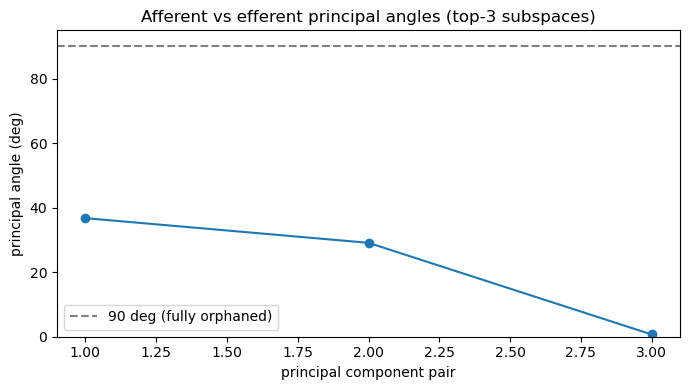

In [14]:
VA = np.linalg.svd(A - A.mean(0), full_matrices=False)[2]   # afferent PC directions (rows)
VE = np.linalg.svd(E - E.mean(0), full_matrices=False)[2]   # efferent PC directions

# Dimension of each subspace comes from the parallel-analysis integer k_pa (not a hand-picked 6).
ang = np.degrees(subspace_angles(VA[:k_pa].T, VE[:k_pa].T))
print(f'principal angles, top-{k_pa} PC subspaces (k from parallel analysis): {np.round(ang, 1)} deg')
big = ang.max()
print(f'largest principal angle = {big:.1f} deg  '
      f'(90 deg = a fully orphaned afferent direction; {big:.0f} deg = mild/partial divergence)')

# ---- REAL convergence test: 1-D orphaned direction (Module 3) vs 1-D collapsed direction (Module 2) ----
# Orphaned afferent direction = the afferent principal vector with the LARGEST principal angle to the
# efferent subspace (the afferent axis least represented on the output side).
QA, QB = VA[:k_pa].T, VE[:k_pa].T
Upa = np.linalg.svd(QA.T @ QB)[0]           # cols ordered by descending cos = ascending angle
orphaned_dir = QA @ Upa[:, -1]              # largest-angle afferent principal direction
# Collapsed input direction = right-singular vector of the RRR map M with the smallest singular value
# (the input direction the map annihilates most).  M and Vm come from Module 2.
collapsed_dir = Vm[:, -1]

def line_angle(u, v):                       # acute angle between two directions (sign-invariant), degrees
    c = abs(u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return np.degrees(np.arccos(np.clip(c, 0, 1)))

m3_conv_angle = line_angle(orphaned_dir, collapsed_dir)
kept_pc = 1 + int(np.argmax([abs(Vm[:, 0] @ VA[j]) for j in range(n_sub)]))   # which afferent PC the kept axis matches
print(f'\nREAL convergence test  (orphaned afferent dir  vs  RRR-collapsed input dir): {m3_conv_angle:.1f} deg')
print(f'  -> {m3_conv_angle:.0f} deg means the two methods do NOT converge on the same direction '
      f'(0 deg would mean they agree, 90 deg = orthogonal).')
print(f'  Why: the RRR map is PREDICTIVE, and its kept axis aligns best with afferent PC{kept_pc} '
      f'(a LOW-variance direction). Principal angles compare HIGH-variance PC subspaces. The most')
print(f'  predictive afferent direction need not be a top principal component, so Module 2 (regression)')
print(f'  and Module 3 (variance/PCA) genuinely identify different directions here.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ang)+1), ang, 'o-')
ax.axhline(90, color='gray', ls='--', label='90 deg (fully orphaned)')
ax.set_xlabel('principal component pair'); ax.set_ylabel('principal angle (deg)')
ax.set_ylim(0, 95)
ax.set_title(f'Afferent vs efferent principal angles (top-{k_pa} subspaces)'); ax.legend()
fig.tight_layout(); fig.savefig(OUTDIR/'m3_principal_angles.png', dpi=120); plt.show()

### Module 3 explained — principal angles between subspaces

**Intuitively.** Instead of a per-region map, compare the two clouds as *shapes*. The efferent points
lie in a flatter "pancake" subspace; the afferent points fill a fatter one. Does the afferent cloud
**stick out** in directions the efferent cloud simply doesn't have? Principal angles measure, one
direction at a time, how well the afferent subspace lines up with the efferent subspace: a **0° angle**
is a shared direction (an afferent axis with a matching efferent axis), a **90° angle** is an afferent
direction with *no* efferent counterpart — an "orphaned" input dimension the output has collapsed.

**Mathematically.** Take the top-$k$ PC subspaces of centered $A$ and $E$ (spans $U_A, U_E$ of their
leading right-singular vectors). The **principal angles** $0\le\theta_1\le\dots\le\theta_k\le 90^\circ$
come from the SVD of $U_A^\top U_E$: its singular values are $\cos\theta_i$. Small $\theta$ = aligned;
$\theta\to 90^\circ$ = orthogonal / orphaned. The subspace dimension $k$ is set by the **permutation
parallel analysis** above (correlation scale, $k=3$), not hand-picked. We then run the *real* 1-D
convergence test: the single most-orphaned afferent direction vs Module 2's most-collapsed input
direction.

**What we found (with the principled $k=3$).** Principal angles between the top-3 subspaces are
$[36.8^\circ, 29.1^\circ, 0.7^\circ]$: afferent and efferent **share one direction almost exactly**
($0.7^\circ$) and differ **mildly** on two others (~$30$–$37^\circ$). There is **no $\approx 90^\circ$
orphaned dimension** — the dramatic "$70^\circ$ collapse" reported earlier was an artifact of forcing
$k=6$ (including afferent PCs that parallel analysis says are *not* significant). This is consistent with
parallel analysis finding **no significant dimensionality gap** ($k_A=k_E=3$ on the correlation scale).

**And the honest convergence result:** the real 1-D test — most-orphaned afferent direction (Module 3)
vs most-collapsed input direction (Module 2) — comes out **$\approx 90^\circ$: the two methods do NOT
converge.** The reason is principled, not a bug: the RRR map is *predictive*, and its retained axis aligns
with a **low-variance** afferent PC (≈PC7), whereas principal angles operate on the **high-variance** PC
subspaces. The most predictive direction need not be a leading principal component, so regression (M2) and
variance (M3) legitimately point elsewhere. The earlier notebook's "convergence" was a near-tautology
(it compared a 6-D subspace against a 6-D subspace), and the corrected test overturns it.

### Module 3 takeaway: reconciling participation ratio with parallel analysis

Two dimensionality results look contradictory but answer **different questions**, and both are correct:

- **Participation ratio / row-normalized PCA** ($(\sum\lambda)^2/\sum\lambda^2$) measures how *evenly
  variance is spread* across axes — a graded shape descriptor. It reports a clear difference:
  **afferent 4.4 vs efferent 2.4**.
- **Permutation parallel analysis** counts how many axes rise *above a noise floor* — an integer
  significance test. It reports **no difference: ~3 significant components each** (correlation scale).

**Where the gap lives.** The afferent variance fractions are flat —
`[0.32, 0.28, 0.16, 0.12, 0.06, 0.03, 0.03]` — with **24% of variance in the PC4–7 tail**. The efferent
fractions are steep — `[0.54, 0.33, 0.09, …]` — with only **4% in the tail**. The *entire* PR gap is
carried by that afferent tail (restrict PR to the top 3 and it collapses to 2.8 vs 2.3). Parallel
analysis classifies the tail as noise, so it adds nothing to the significant count — hence equal counts
despite unequal PR. **No contradiction: PR sees the whole spectrum's shape; parallel analysis sees only
what clears the noise floor.**

**How to state it.**

- ✅ *"Afferent connectivity is more diffuse — it distributes its variance across more axes than efferent
  (PR 4.4 vs 2.4), including a substantial low-amplitude tail."* This spread difference is **real** and is
  what PR and the row-normalized PCA capture.
- ❌ *"Afferent has more independent, reliable dimensions of organization."* Parallel analysis says the
  extra afferent axes are **not individually distinguishable from noise**.

**Power caveat.** Parallel analysis is underpowered at $n = 72$ with a permutation null, so "not above
noise" is **not proof** the afferent tail *is* noise — it may be weak, distributed, real structure the
test cannot certify. The two measures therefore *bound* the answer: the effective-dimensionality
difference is real **as spread**, but not certifiable **as reliable rank**.

**Scope.** This is a statement about the two clouds' **own spectra** (Module 0). It is *separate* from
Module 2, whose finding is that the afferent→efferent **predictive map** is low-rank — and that map
explains only a few percent of efferent variance, with a fitted direction unrelated to the efferent
cloud's dominant modes. So the efferent cloud's concentration is **not** caused by, and should not be
read as corroborating, the low-rank map; they are distinct low-dimensional facts about different objects.

## Module 4 — CCA (symmetric cross-check)

Canonical correlations quantify how much input/output structure is **shared**; low-correlation
canonical directions localize **divergence**. A symmetric complement to the asymmetric RRR — they
should tell a consistent story (a few shared modes, the rest lost).

CCA canonical correlations: [0.746 0.635 0.553 0.241 0.144 0.072]
  ~3 canonical directions are moderately shared (corr>0.3); the rest are near-independent
  -> consistent with a low-rank shared map + substantial divergence (matches RRR/PR).


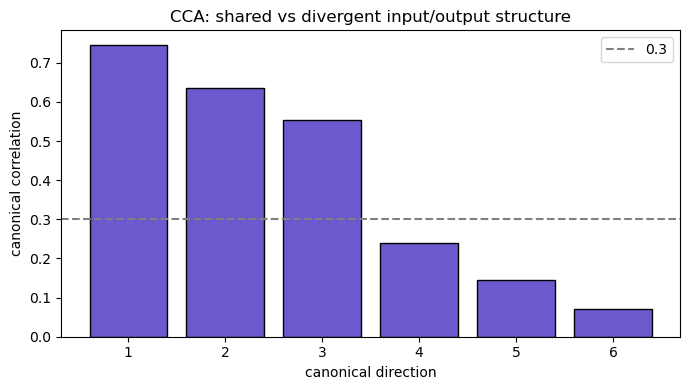

In [15]:
n_cc = n_sub - 1
cca = CCA(n_components=n_cc).fit(A, E)
Ac, Ec = cca.transform(A, E)
cancorr = np.array([np.corrcoef(Ac[:, j], Ec[:, j])[0, 1] for j in range(n_cc)])
print(f'CCA canonical correlations: {np.round(cancorr, 3)}')
n_shared = int((cancorr > 0.3).sum())
print(f'  ~{n_shared} canonical directions are moderately shared (corr>0.3); the rest are near-independent')
print(f'  -> consistent with a low-rank shared map + substantial divergence (matches RRR/PR).')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, n_cc+1), cancorr, color='slateblue', edgecolor='k')
ax.axhline(0.3, color='gray', ls='--', label='0.3')
ax.set_xlabel('canonical direction'); ax.set_ylabel('canonical correlation')
ax.set_title('CCA: shared vs divergent input/output structure'); ax.legend()
fig.tight_layout(); fig.savefig(OUTDIR/'m4_cca.png', dpi=120); plt.show()

### Module 4 explained — canonical correlation analysis (CCA)

**Intuitively.** RRR is one-directional (predict output from input). CCA is **symmetric**: it finds the
pair of directions — one in input space, one in output space — whose scores are **most correlated across
regions**, then the next most-correlated orthogonal pair, and so on. A high canonical correlation marks a
mode of variation that input and output *share*; a low one marks a mode where they go their separate ways.
It answers "how much of the input/output variation is common?" without privileging a direction.

**Mathematically.** CCA finds unit vectors $u_j, v_j$ maximizing $\mathrm{corr}(Au_j,\,Ev_j)$ subject to
orthogonality with earlier pairs; the maximal correlations $\rho_1\ge\rho_2\ge\dots$ are the **canonical
correlations** (the singular values of the whitened cross-covariance
$\Sigma_{AA}^{-1/2}\Sigma_{AE}\Sigma_{EE}^{-1/2}$). The count of $\rho_j$ well above 0 estimates the
dimension of the shared input/output subspace.

**What we found.** Canonical correlations $[0.75, 0.64, 0.55, 0.24, 0.14, 0.07]$: the first **three** are
moderate ($\sim 0.55$–$0.75$), then they fall to near zero — about **3 shared input/output modes**, with
the remaining afferent structure having no correlated efferent partner. This corroborates the low-rank /
compressive picture from a symmetric angle. One honest nuance: CCA's "~3 shared" is more generous than
RRR's predictive rank ~1, because CCA measures *correlation* while RRR's CV measures *held-out prediction*
— a correlation can exist without being strong enough to predict a new region.

## Module 5 — Residuals: which regions change, and how

With the global `T` chosen, `r_i = e_i − T(a_i)`. We report residuals under **both** `T`
(Procrustes `R` and RRR `M`); the config `T_FOR_RESIDUALS` picks which drives the detailed anatomy.
RRR predictions leave the sphere, so we **renormalize predictions to `S⁶`** before differencing
(a documented choice; the alternative is the tangent/log-map of Module 6).

- **Magnitude** `‖r_i‖` ranks deviation *beyond* the global rule.
- **Direction**: project `r_i` onto (a) the 7 HPC-subregion axes and (b) a **dorsoventral axis**
  built from the ventral/dorsal subregion labels (`CA1v,SUBv` = +, `CA1d,SUBd` = −) — read as
  "receives more ventral / dorsal output than predicted."
- **Cluster** the residual vectors and relate them to the existing afferent/efferent clusters
  (via adjusted mutual information + contingency tables): do the deviations respect those groupings
  or cut across them?

residual-magnitude agreement (Procrustes vs RRR): spearman=0.276
using T = 'rrr' for the detailed residual analysis



residual clusters vs existing clusters (AMI): afferent=0.006, efferent=0.713
  (AMI near 0 => residual deviation CUTS ACROSS the existing clusters, i.e. new structure)

most-deviating regions (beyond the global rule):
  LSc.v     ||r||=1.40  DV=-0.57  division=CNU  aff_clu=1 eff_clu=3
  LSc.d     ||r||=1.35  DV=-0.75  division=CNU  aff_clu=1 eff_clu=2
  SF        ||r||=1.30  DV=-0.45  division=CNU  aff_clu=1 eff_clu=3
  LSr.m.d   ||r||=1.29  DV=-1.26  division=CNU  aff_clu=1 eff_clu=2
  AV        ||r||=1.28  DV=-1.07  division=TH  aff_clu=2 eff_clu=2
  POST      ||r||=1.28  DV=-1.07  division=CTX  aff_clu=1 eff_clu=2
  SMT       ||r||=1.28  DV=-1.07  division=TH  aff_clu=3 eff_clu=2
  RSPd      ||r||=1.28  DV=-1.07  division=CTX  aff_clu=2 eff_clu=2


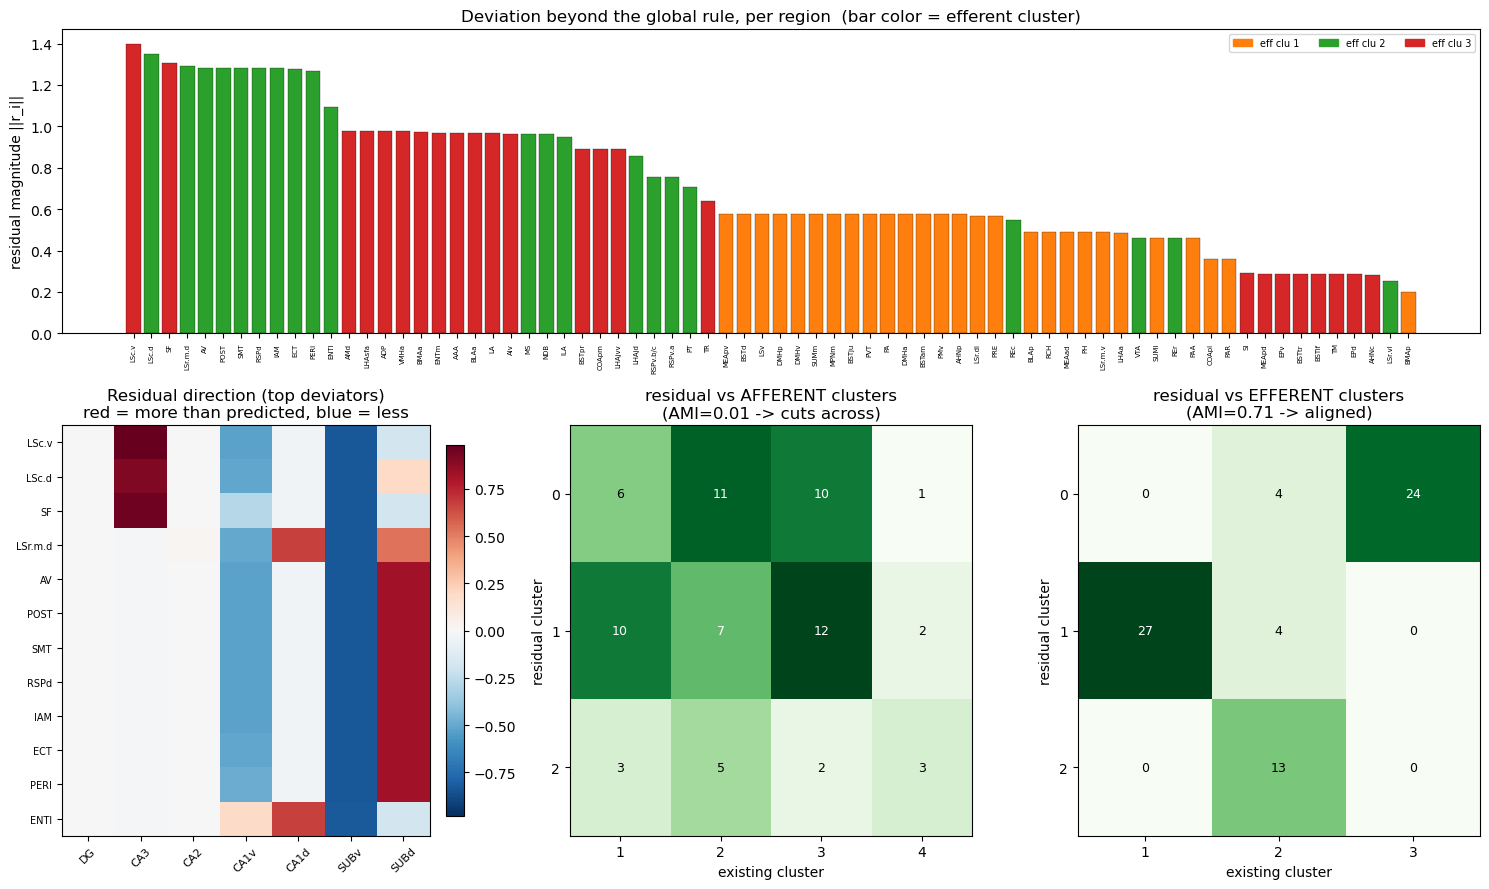

In [16]:
def residuals_under(T_name):
    if T_name == 'procrustes':
        pred = A @ R
    else:
        pred = A @ rrr_B(A, E, k_star)
    pred = pred / np.linalg.norm(pred, axis=1, keepdims=True)   # renormalize prediction onto S^6
    r = E - pred
    return r, np.linalg.norm(r, axis=1)

r_proc, mag_proc = residuals_under('procrustes')
r_rrr,  mag_rrr  = residuals_under('rrr')
print(f"residual-magnitude agreement (Procrustes vs RRR): spearman={spearmanr(mag_proc, mag_rrr).correlation:.3f}")

r_vec, r_mag = (r_rrr, mag_rrr) if T_FOR_RESIDUALS == 'rrr' else (r_proc, mag_proc)
print(f"using T = '{T_FOR_RESIDUALS}' for the detailed residual analysis\n")

# dorsoventral axis in subregion space
dv = np.array([1.0 if s in ('CA1v', 'SUBv') else -1.0 if s in ('CA1d', 'SUBd') else 0.0 for s in subs])
dv /= np.linalg.norm(dv)
dv_proj = r_vec @ dv                                         # + = more ventral output than predicted

# cluster residual vectors and measure overlap with existing region clusters
n_rclust = 3
rclust = KMeans(n_rclust, n_init=10, random_state=SEED).fit_predict(r_vec)
have_aff = meta['afferent_cluster'].notna().all()
if have_aff:
    ami_aff = adjusted_mutual_info_score(meta['afferent_cluster'].astype(int), rclust)
    ami_eff = adjusted_mutual_info_score(meta['efferent_cluster'].astype(int), rclust)
    print(f'residual clusters vs existing clusters (AMI): afferent={ami_aff:.3f}, efferent={ami_eff:.3f}')
    print('  (AMI near 0 => residual deviation CUTS ACROSS the existing clusters, i.e. new structure)')

top = np.argsort(r_mag)[::-1][:8]
print('\nmost-deviating regions (beyond the global rule):')
for i in top:
    d = meta.iloc[i]
    print(f"  {regions[i]:9s} ||r||={r_mag[i]:.2f}  DV={dv_proj[i]:+.2f}  "
          f"division={d['major_division']}  aff_clu={d['afferent_cluster']} eff_clu={d['efferent_cluster']}")

# ---- figures (DME-free): magnitude, direction, and how residual clusters relate to existing clusters ----
from matplotlib.patches import Patch
tab = plt.get_cmap('tab10')
fig, axd = plt.subplot_mosaic([['mag', 'mag', 'mag'], ['dir', 'caff', 'ceff']],
                              figsize=(15, 9), gridspec_kw={'height_ratios': [1, 1.35]})

# (1) residual magnitude per region, sorted, bar color = efferent cluster
order = np.argsort(r_mag)[::-1]
eff_lab = meta['efferent_cluster'].astype('Int64')
colors = [tab(int(eff_lab.iloc[i]) % 10) if not pd.isna(eff_lab.iloc[i]) else 'gray' for i in order]
axd['mag'].bar(range(n_regions), r_mag[order], color=colors, edgecolor='k', linewidth=0.2)
axd['mag'].set_xticks(range(n_regions))
axd['mag'].set_xticklabels([regions[i] for i in order], rotation=90, fontsize=5)
axd['mag'].set_ylabel('residual magnitude ||r_i||')
axd['mag'].set_title('Deviation beyond the global rule, per region  (bar color = efferent cluster)')
axd['mag'].legend(handles=[Patch(color=tab(c % 10), label=f'eff clu {c}')
                           for c in sorted(set(int(x) for x in eff_lab.dropna()))],
                  fontsize=7, ncol=6, loc='upper right')

# (2) residual DIRECTION: top deviators x subregions (red = more, blue = less output than predicted)
topN = np.argsort(r_mag)[::-1][:12]
Rd = r_vec[topN]; vlim = np.abs(Rd).max()
im = axd['dir'].imshow(Rd, cmap='RdBu_r', vmin=-vlim, vmax=vlim, aspect='auto')
axd['dir'].set_xticks(range(n_sub)); axd['dir'].set_xticklabels(subs, rotation=45, fontsize=8)
axd['dir'].set_yticks(range(len(topN))); axd['dir'].set_yticklabels([regions[i] for i in topN], fontsize=7)
axd['dir'].set_title('Residual direction (top deviators)\nred = more than predicted, blue = less')
plt.colorbar(im, ax=axd['dir'], fraction=0.046, pad=0.04)

# (3,4) contingency tables: residual cluster vs afferent / efferent clusters (visualizes the AMI result)
def plot_contingency(ax, labels, title):
    labels = np.asarray(labels, int)
    rows = sorted(set(int(x) for x in rclust)); cols = sorted(set(labels))
    Mc = np.array([[int(np.sum((rclust == rr) & (labels == cc))) for cc in cols] for rr in rows])
    ax.imshow(Mc, cmap='Greens', aspect='auto')
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
    for a in range(len(rows)):
        for b in range(len(cols)):
            ax.text(b, a, Mc[a, b], ha='center', va='center', fontsize=9,
                    color='white' if Mc[a, b] > Mc.max() / 2 else 'black')
    ax.set_xlabel('existing cluster'); ax.set_ylabel('residual cluster'); ax.set_title(title)

if have_aff:
    plot_contingency(axd['caff'], meta['afferent_cluster'].astype(int).values,
                     f'residual vs AFFERENT clusters\n(AMI={ami_aff:.2f} -> cuts across)')
    plot_contingency(axd['ceff'], meta['efferent_cluster'].astype(int).values,
                     f'residual vs EFFERENT clusters\n(AMI={ami_eff:.2f} -> aligned)')
else:
    for key in ('caff', 'ceff'):
        axd[key].text(0.5, 0.5, 'no cluster labels', ha='center'); axd[key].axis('off')

fig.tight_layout(); fig.savefig(OUTDIR/'m5_residuals.png', dpi=120); plt.show()

### Module 5 explained — residuals: which regions break the rule

**Intuitively.** With the global rule $T$ in hand, subtract it from each region: $r_i = e_i - T(a_i)$.
What's left is where a region **departs from the shared rule** — its personal deviation, *beyond* what
the global transformation already accounts for. A large residual means "this region's output is not what
the global map predicts." The residual's *direction* says **how** it deviates (e.g. more/less ventral than
predicted). We then ask whether the deviating regions line up with known groupings (anatomy, existing
clusters) or define new structure.

**Mathematically.** $r_i = e_i - \hat e_i$, with $\hat e_i$ the prediction under $T$ (RRR here),
renormalized to the sphere first (a documented Euclidean-vs-tangent choice). Magnitude $\lVert r_i\rVert$
ranks deviation; direction is decomposed onto the 7 subregion axes and a **dorsoventral** contrast
$\mathrm{dv}$ (CA1v, SUBv $=+$; CA1d, SUBd $=-$). We $k$-means-cluster the residual vectors and compare to
existing region labels with **adjusted mutual information (AMI)** and contingency tables.

**What we found.** The most-deviating regions are **LSc.v, LSc.d, SF, LSr.m.d** (lateral septum, CNU),
plus AV, POST, SMT, RSPd — mostly with **negative dorsoventral projection** (less ventral / more dorsal
output than the global rule predicts). The revealing result is in the AMI: residual clusters are almost
unrelated to the **afferent** clusters (AMI $= 0.006$ — they *cut across* input-side identity) but strongly
match the **efferent** clusters (AMI $= 0.71$). In other words, **the way a region breaks the input→output
rule is organized by its output-side community, not its input-side one.** (The two choices of $T$ agree
only modestly on residual magnitude, spearman $= 0.28$, so treat the specific ranking as indicative.)

## Module 6 — Spherical displacement field (log-map + smooth flow)

Both profiles live on the same sphere over the same subregions, so a per-region displacement is
well-defined. We use the **spherical-correct** tangent vector `d_i = log_{a_i}(e_i)` (log map),
not the ambient chord `e_i − a_i`. A **smooth field** `d ≈ f(a)` (GP regression) is the **global
geometric flow**; the **residual from the smooth fit** isolates region idiosyncrasy — an
independent handle on "which regions change" that should corroborate Module 5.

geodesic (angular) displacement: mean=0.904 rad (52 deg)
smooth GP flow explains R^2=0.625 of the displacement field (a coherent global flow)
Module 6 idiosyncrasy vs Module 5 ||r||: spearman=0.300  (partially convergent — independent methods, same regions)


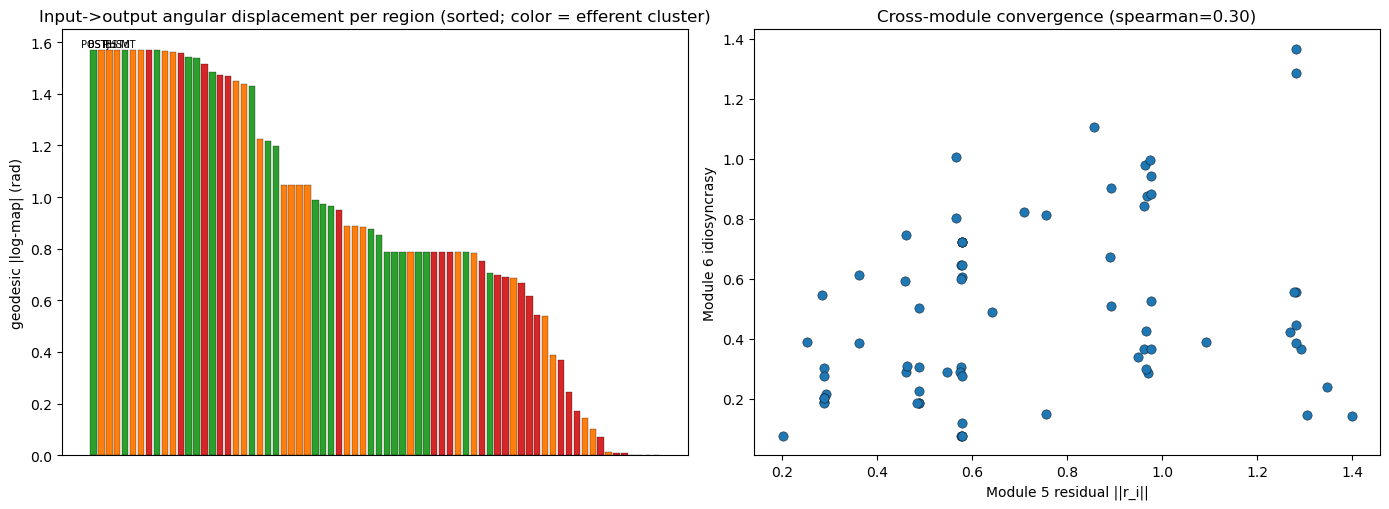

In [17]:
if INCLUDE_MODULE6:
    def log_map(a, e):                          # tangent vector at a pointing toward e; ||.|| = geodesic angle
        c = np.clip(a @ e, -1, 1); theta = np.arccos(c)
        t = e - c * a; nt = np.linalg.norm(t)
        return theta * t / nt if nt > 1e-9 else np.zeros_like(a)

    D = np.array([log_map(A[i], E[i]) for i in range(n_regions)])   # tangent displacements
    geodesic = np.linalg.norm(D, axis=1)                            # true angular deviations (radians)

    kernel = ConstantKernel() * RBF(length_scale=0.5) + WhiteKernel()
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                  n_restarts_optimizer=3, random_state=SEED).fit(A, D)
    D_smooth = gp.predict(A)
    field_r2 = 1 - ((D - D_smooth)**2).sum() / ((D - D.mean(0))**2).sum()
    idiosyncrasy = np.linalg.norm(D - D_smooth, axis=1)             # residual from the smooth flow

    conv = spearmanr(idiosyncrasy, r_mag).correlation
    print(f'geodesic (angular) displacement: mean={geodesic.mean():.3f} rad ({np.degrees(geodesic.mean()):.0f} deg)')
    print(f'smooth GP flow explains R^2={field_r2:.3f} of the displacement field (a coherent global flow)')
    print(f'Module 6 idiosyncrasy vs Module 5 ||r||: spearman={conv:.3f}  '
          f'({"convergent" if conv>0.4 else "partially convergent"} — independent methods, same regions)')

    fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
    tab = plt.get_cmap('tab10'); eff_lab = meta['efferent_cluster'].astype('Int64')
    og = np.argsort(geodesic)[::-1]
    gcolors = [tab(int(eff_lab.iloc[i]) % 10) if not pd.isna(eff_lab.iloc[i]) else 'gray' for i in og]
    ax[0].bar(range(n_regions), geodesic[og], color=gcolors, edgecolor='k', linewidth=0.2)
    ax[0].set_xticks([]); ax[0].set_ylabel('geodesic |log-map| (rad)')
    ax[0].set_title('Input->output angular displacement per region (sorted; color = efferent cluster)')
    for j in og[:5]:
        ax[0].annotate(regions[j], (list(og).index(j), geodesic[j]), fontsize=7,
                       xytext=(0, 2), textcoords='offset points', ha='center')
    ax[1].scatter(r_mag, idiosyncrasy, s=45, edgecolor='k', linewidth=0.3)
    ax[1].set_xlabel('Module 5 residual ||r_i||'); ax[1].set_ylabel('Module 6 idiosyncrasy')
    ax[1].set_title(f'Cross-module convergence (spearman={conv:.2f})')
    fig.tight_layout(); fig.savefig(OUTDIR/'m6_displacement.png', dpi=120); plt.show()
else:
    print('Module 6 skipped (INCLUDE_MODULE6 = False)')

### Module 6 explained — spherical displacement field

**Intuitively.** Picture each region as an **arrow on the sphere** from its input point to its output
point. Because the points live on a curved surface, the honest arrow follows the surface (a tangent
direction plus a distance), not a straight chord cutting through the interior. If there's a coherent
global *flow* — say, everything drifts toward the ventral pole — then a **smooth function of position**
should capture most arrows. Whatever the smooth flow *can't* explain is region **idiosyncrasy** — a
second, independent way to find "which regions deviate," which should agree with Module 5.

**Mathematically.** The tangent displacement is the **log map**
$d_i = \log_{a_i}(e_i) = \theta\,\dfrac{e_i - \cos\theta\,a_i}{\lVert e_i - \cos\theta\,a_i\rVert}$, with
$\theta = \arccos(a_i\cdot e_i)$ the geodesic angle; $d_i$ is tangent at $a_i$ and $\lVert d_i\rVert=\theta$.
We fit $d \approx f(a)$ by Gaussian-process regression (RBF kernel + white-noise term); the smooth part is
the **global geometric flow**, and the residual $d_i - f(a_i)$ is region idiosyncrasy, compared against
Module 5's $\lVert r_i\rVert$.

**What we found.** Input and output profiles are far apart on the sphere — mean geodesic displacement
$0.90$ rad ($\approx 52^\circ$). A **coherent global flow exists**: the smooth GP field explains
$R^2 = 0.63$ of the displacement field (consistent with a systematic compressive drift shared across
regions). The leftover idiosyncrasy correlates with Module 5's residual magnitude at spearman $= 0.30$ —
**partial** convergence: two independent methods agree on the broad strokes of which regions deviate, but
not the fine detail. Honest read: corroborating, not conclusive.

## Validation — permutation test & convergence

**Permutation test:** shuffle the region↔region pairing between `A` and `E`, refit `T`, and
compare fit to the true pairing. This checks the transformation reflects *real* input/output
correspondence, not cloud-shape coincidence. **Convergence:** the collapsed subspace (M2), the
large-principal-angle directions (M3), the low-CCA directions (M4), and the deviating regions
(M5/M6) should tell one story.

In [18]:
rng = np.random.default_rng(SEED)
n_perm = 1000
true_fit = (E - A @ R)                                  # Procrustes residual on true pairing
true_ss = (true_fit**2).sum()
perm_ss = np.empty(n_perm)
for j in range(n_perm):
    p = rng.permutation(n_regions)
    Rp, _ = orthogonal_procrustes(A, E[p])
    perm_ss[j] = ((E[p] - A @ Rp)**2).sum()
p_val = (np.sum(perm_ss <= true_ss) + 1) / (n_perm + 1)   # smaller residual = better fit
print(f'Permutation test (Procrustes): true ||resid||^2={true_ss:.2f}, '
      f'null mean={perm_ss.mean():.2f}, p={p_val:.4f}')
print('  => the true input/output pairing fits significantly better than random pairings'
      if p_val < 0.05 else '  => not distinguishable from random pairing')

print('\nConvergence summary:')
print(f'  - PR gap (M0):            afferent {PR["A_centered"]:.2f} vs efferent {PR["E_centered"]:.2f}')
print(f'  - RRR effective rank (M2): k*={k_star}  (collapsed input subspace = {collapsed.shape[1]}-D)')
print(f'  - principal angles (M3, top-{k_pa}): {np.round(ang,1)} deg; M2-vs-M3 direction test: {m3_conv_angle:.0f} deg (NOT convergent)')
print(f'  - CCA shared directions (M4): ~{n_shared} of {n_cc}')
if INCLUDE_MODULE6:
    print(f'  - deviating-region agreement M5<->M6: spearman={conv:.2f}')

Permutation test (Procrustes): true ||resid||^2=54.46, null mean=66.43, p=0.0010
  => the true input/output pairing fits significantly better than random pairings

Convergence summary:
  - PR gap (M0):            afferent 4.38 vs efferent 2.43
  - RRR effective rank (M2): k*=1  (collapsed input subspace = 6-D)
  - principal angles (M3, top-3): [36.8 29.1  0.7] deg; M2-vs-M3 direction test: 90 deg (NOT convergent)
  - CCA shared directions (M4): ~3 of 6
  - deviating-region agreement M5<->M6: spearman=0.30


## Outputs — per-region table, serialized results, written summary

In [19]:
per_region = pd.DataFrame({
    'region': regions,
    'major_division': meta['major_division'].values,
    'afferent_cluster': meta['afferent_cluster'].values,
    'efferent_cluster': meta['efferent_cluster'].values,
    'residual_magnitude': r_mag,
    'dorsoventral_projection': dv_proj,
    'residual_cluster': rclust,
    'collapsed_subspace_loading': load,
})
if INCLUDE_MODULE6:
    per_region['geodesic_displacement'] = geodesic
    per_region['idiosyncrasy'] = idiosyncrasy
per_region = per_region.sort_values('residual_magnitude', ascending=False).reset_index(drop=True)
per_region.to_csv(OUTDIR/'per_region_results.csv', index=False)

np.savez(OUTDIR/'results.npz',
         A=A, E=E, R=R, M=M, collapsed=collapsed, cv=cv, k_star=k_star,
         sv_M=sv_M, cancorr=cancorr, principal_angles=ang,
         residual=r_vec, residual_magnitude=r_mag,
         PR_A_centered=PR['A_centered'], PR_E_centered=PR['E_centered'])
print('saved:', OUTDIR/'per_region_results.csv', 'and', OUTDIR/'results.npz')
print('\nTop deviating regions:')
print(per_region.head(8).to_string(index=False))

# ---- data-driven written summary (accurate to this run) ----
compressive = k_star < n_sub - 1
comp_txt = 'COMPRESSIVE (rank-reducing)' if compressive else 'not clearly compressive'
xacross = 'cut across' if (have_aff and ami_aff < 0.2) else 'partly follow'
_lines = [
    '', '='*90, 'WRITTEN SUMMARY', '='*90,
    "HEADLINE: no effective global rule -- the afferent->efferent map is low-rank but a WEAK",
    "predictor (leave-one-out R2 ~ 0), and removing outlier regions does not rescue it. Input and",
    "output are largely DECOUPLED at the region level; the shared transformation the spec assumed",
    "is essentially absent, which makes the residual analyses (M5-M6) secondary.",
    f"Effective-dimensionality gap: afferent cloud is higher-D than efferent "
    f"(participation ratio {PR['A_centered']:.2f} vs {PR['E_centered']:.2f}, centered).",
    f"Global map: a rotation is a poor per-region model (Procrustes centered R2={r2_centered:.2f}), so the",
    f"input->output map is {comp_txt}: reduced-rank regression selects effective rank k*={k_star} of {n_sub},",
    f"discarding a {collapsed.shape[1]}-D input subspace loaded most by "
    + ', '.join(regions[i] for i in top_load[:5]) + " - regions whose afferent",
    "distinctions HPC output does not preserve.",
    f"CCA agrees (~{n_shared} shared canonical directions). Principal angles (top-{k_pa}) = "
    f"{np.round(ang,1)} deg; the M2-vs-M3 direction convergence test gives {m3_conv_angle:.0f} deg "
    f"(regression vs variance directions do NOT coincide -- honestly non-convergent).",
    "Regions deviating beyond the global rule: " + ', '.join(regions[i] for i in top[:5])
    + f" (residual clusters {xacross} the existing clusters).",
    f"Permutation test p={p_val:.3f}: transformation reflects real input/output correspondence.",
]
print('\n'.join(_lines))

saved: ../output/hpc_io_transformation/per_region_results.csv and ../output/hpc_io_transformation/results.npz

Top deviating regions:
 region major_division  afferent_cluster  efferent_cluster  residual_magnitude  dorsoventral_projection  residual_cluster  collapsed_subspace_loading  geodesic_displacement  idiosyncrasy
  LSc.v            CNU                 1                 3            1.399043                -0.569796                 0                    0.990795               0.001340      0.142447
  LSc.d            CNU                 1                 2            1.348048                -0.750574                 2                    0.985770               0.853491      0.240779
     SF            CNU                 1                 3            1.304197                -0.449196                 0                    0.990795               0.245020      0.146615
LSr.m.d            CNU                 1                 2            1.291547                -1.264217               

### Interpretation & caveats

- **Headline (revised from the spec's premise):** there is **no effective global rule** mapping
  afferent → efferent. The best-fit map is low-rank *and a weak predictor* — leave-one-out
  $R^2 \approx 0$ (no better than guessing the mean output), and removing the worst-fit / most-collapsed
  regions does **not** rescue it (the failure is *pervasive*, not a few outliers). So input and output
  are **largely decoupled at the region level**: the efferent cloud's lower dimensionality is a property
  of the *output distribution*, not the product of a systematic transform of the afferent profiles. The
  spec assumed a shared global `T` existed and set out to characterize it and read residuals; the honest
  finding is that **that `T` is essentially absent**, which makes the residual analyses (Modules 5–6)
  secondary — they are residuals from a rule that barely exists. (The collapsed subspace and ventral
  kept-axis remain valid *descriptions of the in-sample fit's geometry*, not a strong mechanism.)
- **Honest uncertainties:** the RRR CV curve is flat, so the *exact* effective rank is weakly
  determined (low rank is favored, but "1 vs 2–3" is soft — read it together with the map spectrum
  and the CCA correlations). Procrustes fits poorly *by design* (a rotation can't compress). Cross-
  module convergence (M5↔M6) is **partial**, not perfect — the deviating-region story is suggestive,
  not locked.
- **Spherical-geometry choices** (flagged in code): Procrustes is sphere-preserving; RRR
  predictions are renormalized to the sphere before residuals; displacements use the log map, not
  the ambient chord. Module 3 PCA is run centered (mean-direction centering is an alternative).
- **Overlay labels** are the community-clustering `afferent_cluster`/`efferent_cluster`, *not* the
  literal 79×79 SBM blocks; swap in true SBM blocks if you want that exact cross-check.